In [1]:
# Einmalige Installation der dokumentierten Abhängigkeiten:
# %pip install -r requirements.txt

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from IPython.display import display
from matplotlib.ticker import PercentFormatter

#### Analyseverfahren mit CRISP-DM
1. Business Understanding: Was wollen wir herausfinden?
2. Data Understanding / EDA: Was steckt tatsächlich in den Daten?
3. Data Preparation: Wie behandeln wir Missing Values und Features?
4. Modeling: Welche Modelle/Strategien testen wir konkret?
5. Evaluation: Welche Strategie funktioniert wie gut und wie stabil?

# Business Understanding - Was wollen wir herausfinden?

### Dataset Information
#### **Thema:** Chronische Nierenerkrankung (Chronic Kidney Disease, CKD)
#### **Klassen:** Patienten mit CKD und Patienten ohne CKD
#### **Zielvariable:** ckd/ notckd

#### **Datentyp:** Klinische Patientendaten
#### **Umfang:** 400 Patienten, 24 Merkmale
#### **Enthaltene Daten:**
- demografisch: Alter
- klinisch: Blutdruck, Begleiterkrankungen und Symptome
- Blut-/Laborwerte: z. B. Kreatinin, Harnstoff, Hämoglobin, Natrium, Kalium, Blutzucker
- Urinparameter: z. B. spezifisches Gewicht, Albumin, Zucker, rote Blutkörperchen, Eiterzellen, Bakterien
- weitere klinische Merkmale: Bluthochdruck, Diabetes, koronare Herzkrankheit, Appetit, Ödeme und Anämie
#### **Erhebung:** Krankenhausdaten über einen Zeitraum von ungefähr zwei Monaten
#### **Besonderheit:** Der Datensatz enthält fehlende Werte
#### **URL:** https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease
#### **Doi:** 10.24432/C5G020
 
#### **Problemstellung:**

Chronische Nierenerkrankungen können mit verschiedenen klinischen und laborchemischen Veränderungen einhergehen. In der medizinischen Praxis kann es hilfreich sein zu untersuchen, ob sich Patienten mit CKD anhand bereits erhobener klinischer Daten und Laborwerte von Patienten ohne CKD unterscheiden lassen.

#### Ziel: 
Untersuchen, ob sich CKD-Patienten anhand der vorhandenen Merkmale von Patienten ohne CKD unterscheiden lassen und ob auf dieser Grundlage eine zuverlässige Klassifikation möglich ist.

#### Dabei sollen insbesondere folgende Fragen beantwortet werden:

1. Welche Merkmale unterscheiden sich zwischen CKD und Nicht-CKD?
2. Welche Merkmale tragen besonders zur Unterscheidung der beiden Klassen bei?
3. Lässt sich der CKD-Status anhand der vorhandenen Daten zuverlässig klassifizieren?
4. Kann eine vergleichbare Klassifikationsleistung bereits mit einer kleineren Anzahl von Merkmalen erreicht werden?
5. Welchen Einfluss hat der Umgang mit fehlenden Werten auf die Klassifikationsleistung?
 - z. B. Imputation
 - Verfahren, die Missing Values direkt verarbeiten können
 - Complete Cases gegebenenfalls als Vergleichs-/Sensitivitätsanalyse


# Data Understanding / Explorative Datenanalyse (EDA) - Was steckt tatsächlich in den Daten?

### Dataset overview


In [14]:
%load_ext autoreload
%autoreload 2
from src import ckd_WORK
# Reproduzierbarer Ladeweg: lokale CSV; nur falls sie fehlt, UCI-Fallback.
# Datenquelle: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease
data_raw, classes, parameters, parameter_names = (ckd_WORK.load_ckd_dataset())
data_clean = ckd_WORK.clean_ckd_data(data_raw)
total, complete, incomplete = (ckd_WORK.split_by_completeness(data_clean))
print("Anzahl Zeilen/Stichproben: ", len(data_raw))
print(total)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Anzahl Zeilen/Stichproben:  400
      age    bp     sg   al   su     rbc        pc         pcc          ba  \
0    48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1     7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2    62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3    48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4    51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   
..    ...   ...    ...  ...  ...     ...       ...         ...         ...   
395  55.0  80.0  1.020  0.0  0.0  normal    normal  notpresent  notpresent   
396  42.0  70.0  1.025  0.0  0.0  normal    normal  notpresent  notpresent   
397  12.0  80.0  1.020  0.0  0.0  normal    normal  notpresent  notpresent   
398  17.0  60.0  1.025  0.0  0.0  normal    normal  notpresent  notpresent   
399  58.0  80.0  1.025

### Parameter

In [9]:
# variable information  , 
# https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease
print("----------- Untersuche Parameter -----------")
print(parameter_names) # Spalten namen


----------- Untersuche Parameter -----------
     name              description
0     age                      NaN
1      bp           blood pressure
2      sg         specific gravity
3      al                  albumin
4      su                    sugar
5     rbc          red blood cells
6      pc                 pus cell
7     pcc          pus cell clumps
8      ba                 bacteria
9     bgr     blood glucose random
10     bu               blood urea
11     sc         serum creatinine
12    sod                   sodium
13    pot                potassium
14   hemo               hemoglobin
15    pcv       packed cell volume
16   wbcc   white blood cell count
17   rbcc     red blood cell count
18    htn             hypertension
19     dm        diabetes mellitus
20    cad  coronary artery disease
21  appet                 appetite
22     pe              pedal edema
23    ane                   anemia
24  class           ckd or not ckd


**Urin:** sg, al, su, rbc, pc, pcc, ba

**Blut/Labor:** bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc

**Andere:** age, bp, htn, dm, cad, appet, pe, ane

**Zielvariable:** class


### WICHTIG! 
Ich werde nicht den Sinn der Merkmale mir anschauen. Das führt zu Confirmation BIAS und einer unsauberen Datenanalyse.

#### Technische Grundbereinigung
Textwerte, Datentypen, ?, Zielvariable und Duplikate.

In [ ]:
# Zugriff auf alle Zeilen (:), aber nur die zweite Spalte (1)

for par in total.columns:
    print(f"---- parameter -----", par)
    for wert in total[par].unique():
        print(repr(wert))


### Missing Values

#### Frage 1: Wie viele Zeilen sind komplett und wie viele unvolständig.

In [ ]:
total = data_raw
print("Anzahl aller Zeilen", len(data_raw))


complete = total.loc[total.notna().all(axis=1)].copy()
print("Zeilen ohne einen einzigen fehlenden Wert", len(complete), ". Das heißt ", len(complete)/len(total)*100, "% sind vollständig")

incomplete = total.loc[total.isna().any(axis=1)].copy()

print("Zeilen mit mindestens einem fehlenden Wert ", len(incomplete), ". Das heißt ", len(incomplete)/len(total)*100, "% sind unvollständig" )

#### Frage 2: Systematische Fehler müssen erkannt werden pro Parameter und ggbf. Normalerweise gibt es danach eine Rücksprache mit dem Team warum es zu dieses Systematischen fehlern gekommen ist. Missind compleatly at Random (MCAR), Mising at Random (MMAR) ?

### Publikation gelesen. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC11799517/?utm_source=chatgpt.com

Die UCI-Seite sagt im Kern Der Datensatz wurde 2015 bereitgestellt: 400 Patienten, 24 Variablen, über etwa zwei Monate in einem Krankenhaus erhoben. Toll.
Fehlende Werte werden erwähnt, Aber nicht begründet :) Noch bessser.
Es gibt keine saubere Beschreibung des Erhebungsprotokolls oder warum bestimmte Messungen fehlen. Das heißt ...

### Das Studiendesign ist nicht ausreichend dokumentiert, um den Missing-Mechanismus eindeutig zu bestimmen. 

In [ ]:
total.describe()


In [ ]:
total

#### Analyse
Erste Spalte patient_id momentan unbrauchbar. Wird erstmal entfernt
Median ist nicht dabei, mean ist empfindlich gegen ausreiser. 
Boxplots nötig zur besseren visuellen analyse.

In [ ]:
num_data = total.select_dtypes(include=['float64'])
num_data.boxplot()
plt.show()

#### Analyse:
Wir speichern Separat wbcc

In [ ]:

num_data_without_wbcc = num_data.drop(columns=["wbcc"])

num_data_without_wbcc.boxplot()
plt.show()

#### Analyse:
Wir sehen hier viele unterschiedliche Boxplots mit ausreisern und müssen jetzt im nächsten Schritt einelne Boxplots mit ihren histogrammen sehen und den Ausreisern. ich muss mir genau die Parameter anschauen befor ich die nächste Entscheidung treffe was ich weiter mache.

In [ ]:
from src.ckd_funktionen import plot_all_ckd_distributions

table = plot_all_ckd_distributions( features=total, classes=classes, )

In [ ]:
# Fehlende Werte pro Parameter

missing_summary = pd.DataFrame(
    {
        "Anzahl fehlend": total.isna().sum(),
        "Anteil fehlend (%)": (
            total.isna().mean() * 100
        ).round(2),
    }
)

missing_summary = missing_summary.sort_values(
    by="Anzahl fehlend",
    ascending=False,
)

display(missing_summary)

#### Kann es sein das die Fehlenden Werte Einfluss haben werden auf unsere Modelle?
$H_0:$ Es besteht KEIN Zusammenhang zwischen CKD-Status und fehlenden Werten

$H_1:$ Es besteht ein Zusammenhang zwischen CKD-Status und fehlenden Werten

In [ ]:
from scipy.stats import fisher_exact

res = fisher_exact(
    table,
    alternative="two-sided"
)

print("Odds Ratio:", res.statistic)
print("p-Wert:", res.pvalue)

Der Fisher-Test zeigt: Missingness (das Fehlen der Daten) und CKD-Status (ob jemand Krank ist oder nicht) hängen in diesen Datensatz zusammen.

Maßgebliche Fallzahlen nach der dokumentierten technischen Bereinigung: 158 von 400 Fällen (39,5 %) sind vollständig und 242 von 400 Fällen (60,5 %) enthalten mindestens einen fehlenden Wert.

Chronische Nierenerkrankung (CKD):
207 von 250 Patienten (82,8 %) haben mindestens einen fehlenden Wert. Nur 43 Fälle sind vollständig. Bei CKD-Patienten fehlen somit deutlich häufiger Messwerte.

Gesunde (notCKD):
35 von 150 Patienten (23,3 %) haben mindestens einen fehlenden Wert. 115 Fälle (76,7 %) sind vollständig.
Bei Patienten die Krank sind wurden nicht immer Urin und Blutdaten eingetragen. 
**Warum, wissen wir nicht.**

[WICHTIGE INFO] In dem Falle müsste man die Ärzte, welche die Studie durchgeführt haben, danach Fragen **warum gerade bei Kranken Patienten Messungen an vielen Stellen fehlen.**

**Risiko: Selection Bias**

Wenn nur vollständige Fälle verwendet werden, werden überproportional viele CKD-Patienten ausgeschlossen. Dadurch entsteht eine systematisch veränderte Stichprobe. Das nennt man Selection Bias.

**[PROBLEM der KI Architekten]**

Modell lernt dann -> wenn Daten fehlen dann ist der Patient Krank. Nach dem Motto es gibt keine Urinprobe -> oh dann ist der Patient bestimmt an Niereninsufizienz erkrank.

Es lernt später das Muster der Datenerhebung anstatt das Muster der Krankheit aus den Daten.





Der Modellvergleich später beantwortet etwas anderes, nämlich ob unterschiedliche Strategien zum Umgang mit fehlenden Werten zu unterschiedlichen Vorhersageleistungen führen. Das ist eine Aussage über Modell-Performance, nicht über Ursache. Du zeigst also nicht CKD verursacht Missing Values oder Missing Values verursachen CKD... Du sagst... Missingness ist mit der Zielklasse assoziiert, und... deshalb testen wir, ob die Wahl der Missing-Data-Strategie die Modellleistung verändert... Das ist die saubere Kette...

# Änderung der Entscheidung: Volständige Daten können nicht mehr die Baseline representieren.

In [ ]:
# ============================================================
# RANDOM FOREST UND MISSING VALUES
#
# Modell A:
# Imputation ohne Missing-Indikatoren
#
# Modell B:
# Imputation mit Missing-Indikatoren
#
# Evaluation:
# - stratifizierte 5-fache Kreuzvalidierung
# - abschließende Bewertung auf separaten Testdaten
# ============================================================


# ============================================================
# 1. BIBLIOTHEKEN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 2. DATEN VORBEREITEN
# ============================================================

X = total.copy()

# classes ist ein separater DataFrame.
# Die erste Spalte enthält ckd beziehungsweise notckd.
y_text = classes.iloc[:, 0].copy()

# Textwerte vereinheitlichen
y_text = (
    y_text
    .astype(str)
    .str.strip()
    .str.lower()
)

# Zielvariable binär kodieren:
# 1 = CKD
# 0 = keine CKD
y = y_text.map(
    {
        "ckd": 1,
        "notckd": 0,
    }
)

# Prüfen, ob unbekannte Zielklassen vorhanden sind
if y.isna().any():

    unbekannte_klassen = (
        y_text[y.isna()]
        .unique()
    )

    raise ValueError(
        "Unbekannte Werte in der Zielvariable: "
        f"{unbekannte_klassen}"
    )


print("Klassenverteilung:")

print(
    y.map(
        {
            1: "ckd",
            0: "notckd",
        }
    ).value_counts()
)


# ============================================================
# 3. NUMERISCHE UND KATEGORIALE SPALTEN
# ============================================================

numerische_spalten = (
    X.select_dtypes(
        include="number"
    )
    .columns
    .tolist()
)

kategoriale_spalten = (
    X.select_dtypes(
        exclude="number"
    )
    .columns
    .tolist()
)


print("\nNumerische Spalten:")

print(numerische_spalten)


print("\nKategoriale Spalten:")

print(kategoriale_spalten)


# ============================================================
# 4. TRAININGS- UND TESTDATEN
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)


print("\nAnzahl Trainingsdaten:", len(X_train))

print("Anzahl Testdaten:", len(X_test))


print("\nKlassenverteilung der Trainingsdaten:")

print(
    y_train
    .map(
        {
            1: "ckd",
            0: "notckd",
        }
    )
    .value_counts()
)


print("\nKlassenverteilung der Testdaten:")

print(
    y_test
    .map(
        {
            1: "ckd",
            0: "notckd",
        }
    )
    .value_counts()
)


# ============================================================
# 5. PIPELINE ERSTELLEN
# ============================================================

def create_random_forest_pipeline(
    add_missing_indicators=False,
):
    """
    Erstellt eine Random-Forest-Pipeline.

    Numerische Variablen:
    - Median-Imputation

    Kategoriale Variablen:
    - Modus-Imputation
    - One-Hot-Encoding

    Optional:
    - Missing-Indikatoren
    """

    # Numerische Variablen
    numerische_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=add_missing_indicators,
                ),
            ),
        ]
    )

    # Kategoriale Variablen
    kategoriale_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                    add_indicator=add_missing_indicators,
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    # Numerische und kategoriale Verarbeitung verbinden
    vorverarbeitung = ColumnTransformer(
        transformers=[
            (
                "numerisch",
                numerische_pipeline,
                numerische_spalten,
            ),
            (
                "kategorial",
                kategoriale_pipeline,
                kategoriale_spalten,
            ),
        ]
    )

    # Random Forest
    random_forest = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    # Vollständige Pipeline
    pipeline = Pipeline(
        steps=[
            (
                "vorverarbeitung",
                vorverarbeitung,
            ),
            (
                "modell",
                random_forest,
            ),
        ]
    )

    return pipeline


# ============================================================
# 6. MODELLE ERSTELLEN
# ============================================================

modell_a = create_random_forest_pipeline(
    add_missing_indicators=False
)

modell_b = create_random_forest_pipeline(
    add_missing_indicators=True
)


# ============================================================
# 7. BEWERTUNGSMETRIKEN
# ============================================================

# Sensitivität:
# Anteil der tatsächlich Erkrankten,
# die korrekt als CKD erkannt werden.
sensitivitaet_scorer = make_scorer(
    recall_score,
    pos_label=1,
)

# Spezifität:
# Anteil der tatsächlich Gesunden,
# die korrekt als notckd erkannt werden.
spezifitaet_scorer = make_scorer(
    recall_score,
    pos_label=0,
)

# Precision:
# Anteil der als CKD vorhergesagten Personen,
# die tatsächlich CKD haben.
precision_scorer = make_scorer(
    precision_score,
    pos_label=1,
    zero_division=0,
)

# F1-Score:
# Kombination aus Precision und Sensitivität.
f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0,
)

# Alle Bewertungsmetriken
scoring = {
    "Accuracy": "accuracy",
    "Balanced Accuracy": "balanced_accuracy",
    "Precision": precision_scorer,
    "Sensitivität": sensitivitaet_scorer,
    "Spezifität": spezifitaet_scorer,
    "F1-Score": f1_scorer,
    "ROC-AUC": "roc_auc",
}


# ============================================================
# 8. STRATIFIZIERTE KREUZVALIDIERUNG
# ============================================================

# Die Trainingsdaten werden in fünf Folds aufgeteilt.
# In jedem Fold bleibt die Klassenverteilung erhalten.
kreuzvalidierung = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


def evaluate_cross_validation(
    modell,
    modell_name,
):
    """
    Führt eine stratifizierte 5-fache
    Kreuzvalidierung auf den Trainingsdaten durch.

    Gibt Mittelwert und Standardabweichung
    der Bewertungsmetriken zurück.
    """

    print("\n" + "=" * 60)

    print(
        f"Starte Kreuzvalidierung: {modell_name}"
    )

    print(
        "Das Modell wird jetzt fünfmal trainiert und geprüft."
    )

    print("=" * 60)

    cv_ergebnis = cross_validate(
        estimator=modell,
        X=X_train,
        y=y_train,
        cv=kreuzvalidierung,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,

        # Zeigt den Fortschritt in Jupyter an
        verbose=10,
    )

    print(
        f"\nKreuzvalidierung abgeschlossen: {modell_name}"
    )

    zeilen = []

    for metrik in scoring:

        werte = cv_ergebnis[
            f"test_{metrik}"
        ]

        zeilen.append(
            {
                "Modell": modell_name,
                "Metrik": metrik,
                "Mittelwert": werte.mean(),
                "Standardabweichung": werte.std(),
                "Minimum": werte.min(),
                "Maximum": werte.max(),
            }
        )

    return pd.DataFrame(zeilen)


# ============================================================
# 9. KREUZVALIDIERUNG MODELL A
# ============================================================

print(
    "\nStarte Modell A: "
    "Imputation ohne Missing-Indikatoren"
)

cv_modell_a = evaluate_cross_validation(
    modell=modell_a,
    modell_name="Imputation",
)

print(
    "\nModell A wurde vollständig geprüft."
)


# ============================================================
# 10. KREUZVALIDIERUNG MODELL B
# ============================================================

print(
    "\nStarte Modell B: "
    "Imputation mit Missing-Indikatoren"
)

cv_modell_b = evaluate_cross_validation(
    modell=modell_b,
    modell_name=(
        "Imputation + Missing-Indikatoren"
    ),
)

print(
    "\nModell B wurde vollständig geprüft."
)


# ============================================================
# 11. ERGEBNISSE DER KREUZVALIDIERUNG
# ============================================================

cv_ergebnisse = pd.concat(
    [
        cv_modell_a,
        cv_modell_b,
    ],
    ignore_index=True,
)


print(
    "\nErgebnisse der stratifizierten "
    "5-fachen Kreuzvalidierung:"
)

display(
    cv_ergebnisse.round(3)
)


# ============================================================
# 12. KREUZVALIDIERUNG ALS VERGLEICHSTABELLE
# ============================================================

cv_mittelwerte = cv_ergebnisse.pivot(
    index="Metrik",
    columns="Modell",
    values="Mittelwert",
)

print(
    "\nMittlere Modellleistung "
    "über die fünf Folds:"
)

display(
    cv_mittelwerte.round(3)
)


cv_standardabweichungen = cv_ergebnisse.pivot(
    index="Metrik",
    columns="Modell",
    values="Standardabweichung",
)

print(
    "\nStandardabweichung "
    "über die fünf Folds:"
)

display(
    cv_standardabweichungen.round(3)
)


# ============================================================
# 13. MODELLE AUF ALLEN TRAININGSDATEN TRAINIEREN
# ============================================================

print(
    "\nTrainiere Modell A auf allen Trainingsdaten ..."
)

modell_a.fit(
    X_train,
    y_train,
)

print(
    "Modell A wurde trainiert."
)


print(
    "\nTrainiere Modell B auf allen Trainingsdaten ..."
)

modell_b.fit(
    X_train,
    y_train,
)

print(
    "Modell B wurde trainiert."
)


# ============================================================
# 14. FUNKTION ZUR BEWERTUNG DER TESTDATEN
# ============================================================

def evaluate_test_data(
    modell,
    modell_name,
    X_test,
    y_test,
):
    """
    Bewertet ein trainiertes Modell auf den
    zuvor unangetasteten Testdaten.
    """

    # Vorhergesagte Klassen
    vorhersage = modell.predict(
        X_test
    )

    # Vorhergesagte Wahrscheinlichkeit für CKD
    wahrscheinlichkeit_ckd = (
        modell.predict_proba(
            X_test
        )[:, 1]
    )

    # Confusion Matrix
    matrix = confusion_matrix(
        y_test,
        vorhersage,
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrix.ravel()

    # Sensitivität
    sensitivitaet = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    # Spezifität
    spezifitaet = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    ergebnis = {
        "Modell": modell_name,

        "Accuracy": accuracy_score(
            y_test,
            vorhersage,
        ),

        "Balanced Accuracy": (
            balanced_accuracy_score(
                y_test,
                vorhersage,
            )
        ),

        "Precision": precision_score(
            y_test,
            vorhersage,
            pos_label=1,
            zero_division=0,
        ),

        "Sensitivität": sensitivitaet,

        "Spezifität": spezifitaet,

        "F1-Score": f1_score(
            y_test,
            vorhersage,
            pos_label=1,
            zero_division=0,
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            wahrscheinlichkeit_ckd,
        ),

        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
    }

    return ergebnis, matrix


# ============================================================
# 15. TESTDATEN BEWERTEN
# ============================================================

print(
    "\nBewerte Modell A auf den Testdaten ..."
)

test_a, matrix_a = evaluate_test_data(
    modell=modell_a,
    modell_name="Imputation",
    X_test=X_test,
    y_test=y_test,
)

print(
    "Bewertung von Modell A abgeschlossen."
)


print(
    "\nBewerte Modell B auf den Testdaten ..."
)

test_b, matrix_b = evaluate_test_data(
    modell=modell_b,
    modell_name=(
        "Imputation + Missing-Indikatoren"
    ),
    X_test=X_test,
    y_test=y_test,
)

print(
    "Bewertung von Modell B abgeschlossen."
)


# ============================================================
# 16. TESTERGEBNISSE ANZEIGEN
# ============================================================

test_ergebnisse = pd.DataFrame(
    [
        test_a,
        test_b,
    ]
)

print(
    "\nAbschließende Ergebnisse "
    "auf den Testdaten:"
)

display(
    test_ergebnisse.round(3)
)


# ============================================================
# 17. CONFUSION MATRICES
# ============================================================

fig, achsen = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

sns.heatmap(
    matrix_a,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "notckd",
        "ckd",
    ],
    yticklabels=[
        "notckd",
        "ckd",
    ],
    ax=achsen[0],
)

achsen[0].set_title(
    "Modell A: Imputation"
)

achsen[0].set_xlabel(
    "Vorhergesagte Klasse"
)

achsen[0].set_ylabel(
    "Tatsächliche Klasse"
)


sns.heatmap(
    matrix_b,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=[
        "notckd",
        "ckd",
    ],
    yticklabels=[
        "notckd",
        "ckd",
    ],
    ax=achsen[1],
)

achsen[1].set_title(
    "Modell B: Imputation\n"
    "+ Missing-Indikatoren"
)

achsen[1].set_xlabel(
    "Vorhergesagte Klasse"
)

achsen[1].set_ylabel(
    "Tatsächliche Klasse"
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. FEATURE IMPORTANCE VON MODELL B
# ============================================================

vorverarbeitung_b = (
    modell_b
    .named_steps["vorverarbeitung"]
)

random_forest_b = (
    modell_b
    .named_steps["modell"]
)

feature_namen = (
    vorverarbeitung_b
    .get_feature_names_out()
)

feature_importance = pd.DataFrame(
    {
        "Feature": feature_namen,
        "Importance": (
            random_forest_b
            .feature_importances_
        ),
    }
)

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nDie 20 wichtigsten Features "
    "von Modell B:"
)

display(
    feature_importance
    .head(20)
    .round(4)
)


# ============================================================
# 19. FEATURE IMPORTANCE ZEICHNEN
# ============================================================

top_features = (
    feature_importance
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True,
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="steelblue",
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest mit Missing-Indikatoren\n"
    "20 wichtigste Features"
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. NUR MISSING-INDIKATOREN ANZEIGEN
# ============================================================

missing_importance = feature_importance[
    feature_importance["Feature"]
    .str.contains(
        "missing",
        case=False,
    )
].copy()


print(
    "\nFeature Importance "
    "der Missing-Indikatoren:"
)

if missing_importance.empty:

    print(
        "Keine Missing-Indikatoren gefunden."
    )

else:

    display(
        missing_importance.round(4)
    )


print(
    "\nDie vollständige Analyse ist abgeschlossen."
)

In [ ]:
# ============================================================
# RANDOM FOREST NUR MIT COMPLETE CASES
#
# Es werden ausschließlich Patienten verwendet,
# bei denen alle 24 Merkmale vollständig vorliegen.
#
# Keine Imputation
# Keine Missing-Indikatoren
# ============================================================


# ============================================================
# 1. BIBLIOTHEKEN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 2. COMPLETE CASES ERSTELLEN
# ============================================================

# Alle ursprünglichen Merkmale
X_gesamt = total.copy()

# Zielvariable aus dem separaten DataFrame übernehmen
y_text = classes.iloc[:, 0].copy()

# Zielvariable an den Index der Merkmale anpassen
y_text = y_text.reindex(
    X_gesamt.index
)

# Textwerte vereinheitlichen
y_text = (
    y_text
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(
        {
            "not ckd": "notckd",
            "non-ckd": "notckd",
            "nonckd": "notckd",
        }
    )
)

# Nur Zeilen auswählen, in denen kein Wert fehlt
complete_mask = (
    X_gesamt
    .notna()
    .all(axis=1)
)

X_complete = (
    X_gesamt
    .loc[complete_mask]
    .copy()
)

y_complete_text = (
    y_text
    .loc[complete_mask]
    .copy()
)


# ============================================================
# 3. ZIELVARIABLE KODIEREN
# ============================================================

# 1 = CKD
# 0 = keine CKD
y_complete = y_complete_text.map(
    {
        "ckd": 1,
        "notckd": 0,
    }
)

# Unbekannte Klassen überprüfen
if y_complete.isna().any():

    unbekannte_klassen = (
        y_complete_text[
            y_complete.isna()
        ]
        .unique()
    )

    raise ValueError(
        "Unbekannte Werte in der Zielvariable: "
        f"{unbekannte_klassen}"
    )


# ============================================================
# 4. COMPLETE CASES KONTROLLIEREN
# ============================================================

print("=" * 60)

print(
    "RANDOM FOREST NUR MIT COMPLETE CASES"
)

print("=" * 60)

print(
    "\nAnzahl ursprünglicher Patienten:",
    len(X_gesamt),
)

print(
    "Anzahl vollständiger Patienten:",
    len(X_complete),
)

print(
    "Anteil vollständiger Patienten:",
    f"{len(X_complete) / len(X_gesamt) * 100:.2f} %",
)

print(
    "Anzahl ausgeschlossener Patienten:",
    len(X_gesamt) - len(X_complete),
)

print(
    "\nAnzahl fehlender Werte in X_complete:",
    X_complete.isna().sum().sum(),
)

print(
    "Anzahl fehlender Zielwerte:",
    y_complete.isna().sum(),
)


# Sicherheitsprüfung
if X_complete.isna().any().any():

    raise ValueError(
        "X_complete enthält noch fehlende Werte."
    )


# ============================================================
# 5. KLASSENVERTEILUNG
# ============================================================

klassenverteilung_complete = (
    y_complete
    .map(
        {
            1: "ckd",
            0: "notckd",
        }
    )
    .value_counts()
)

print(
    "\nKlassenverteilung der Complete Cases:"
)

print(
    klassenverteilung_complete
)


klassenanteile_complete = (
    y_complete
    .map(
        {
            1: "ckd",
            0: "notckd",
        }
    )
    .value_counts(
        normalize=True
    )
    .mul(100)
)

print(
    "\nProzentuale Klassenverteilung:"
)

print(
    klassenanteile_complete.round(2)
)


# ============================================================
# 6. DUPLIKATE KONTROLLIEREN
# ============================================================

anzahl_duplikate = (
    X_complete
    .duplicated()
    .sum()
)

print(
    "\nAnzahl vollständig identischer Merkmalszeilen:",
    anzahl_duplikate,
)

# Duplikate werden hier nur angezeigt,
# aber nicht automatisch entfernt.


# ============================================================
# 7. TEXTWERTE BEREINIGEN
# ============================================================

for spalte in X_complete.select_dtypes(
    exclude="number"
).columns:

    X_complete[spalte] = (
        X_complete[spalte]
        .astype(str)
        .str.strip()
        .str.lower()
    )


# ============================================================
# 8. NUMERISCHE UND KATEGORIALE SPALTEN
# ============================================================

numerische_spalten = (
    X_complete
    .select_dtypes(
        include="number"
    )
    .columns
    .tolist()
)

kategoriale_spalten = (
    X_complete
    .select_dtypes(
        exclude="number"
    )
    .columns
    .tolist()
)


print(
    "\nNumerische Spalten:"
)

print(
    numerische_spalten
)

print(
    "\nKategoriale Spalten:"
)

print(
    kategoriale_spalten
)


# ============================================================
# 9. TRAININGS- UND TESTDATEN
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_complete,
    y_complete,
    test_size=0.25,
    stratify=y_complete,
    random_state=42,
)


print(
    "\nAnzahl Trainingsdaten:",
    len(X_train),
)

print(
    "Anzahl Testdaten:",
    len(X_test),
)


print(
    "\nKlassenverteilung der Trainingsdaten:"
)

print(
    y_train
    .map(
        {
            1: "ckd",
            0: "notckd",
        }
    )
    .value_counts()
)


print(
    "\nKlassenverteilung der Testdaten:"
)

print(
    y_test
    .map(
        {
            1: "ckd",
            0: "notckd",
        }
    )
    .value_counts()
)


# ============================================================
# 10. PIPELINE OHNE IMPUTATION
# ============================================================

# Numerische Variablen werden unverändert übernommen.
# Kategoriale Variablen werden One-Hot-kodiert.
vorverarbeitung_complete = ColumnTransformer(
    transformers=[
        (
            "numerisch",
            "passthrough",
            numerische_spalten,
        ),
        (
            "kategorial",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            kategoriale_spalten,
        ),
    ]
)


random_forest_complete = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,

    # Die fünf CV-Folds werden bereits parallel berechnet.
    n_jobs=1,
)


modell_complete = Pipeline(
    steps=[
        (
            "vorverarbeitung",
            vorverarbeitung_complete,
        ),
        (
            "modell",
            random_forest_complete,
        ),
    ]
)


# ============================================================
# 11. BEWERTUNGSMETRIKEN
# ============================================================

# Sensitivität:
# Anteil der tatsächlich Erkrankten,
# die korrekt als CKD erkannt werden.
sensitivitaet_scorer = make_scorer(
    recall_score,
    pos_label=1,
)

# Spezifität:
# Anteil der tatsächlich Gesunden,
# die korrekt als notckd erkannt werden.
spezifitaet_scorer = make_scorer(
    recall_score,
    pos_label=0,
)

# Precision:
# Anteil der als CKD klassifizierten Personen,
# die tatsächlich CKD haben.
precision_scorer = make_scorer(
    precision_score,
    pos_label=1,
    zero_division=0,
)

# F1-Score
f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0,
)


scoring = {
    "Accuracy": "accuracy",
    "Balanced Accuracy": "balanced_accuracy",
    "Precision": precision_scorer,
    "Sensitivität": sensitivitaet_scorer,
    "Spezifität": spezifitaet_scorer,
    "F1-Score": f1_scorer,
    "ROC-AUC": "roc_auc",
}


# ============================================================
# 12. STRATIFIZIERTE KREUZVALIDIERUNG
# ============================================================

kreuzvalidierung = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


print("\n" + "=" * 60)

print(
    "Starte stratifizierte 5-fache Kreuzvalidierung"
)

print(
    "Modell: Random Forest nur mit Complete Cases"
)

print("=" * 60)


cv_complete = cross_validate(
    estimator=modell_complete,
    X=X_train,
    y=y_train,
    cv=kreuzvalidierung,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True,
    verbose=10,
)


print(
    "\nKreuzvalidierung abgeschlossen."
)


# ============================================================
# 13. CV-ERGEBNISSE AUFBEREITEN
# ============================================================

cv_complete_zeilen = []

for metrik in scoring:

    test_werte = cv_complete[
        f"test_{metrik}"
    ]

    train_werte = cv_complete[
        f"train_{metrik}"
    ]

    cv_complete_zeilen.append(
        {
            "Modell": "Complete Cases",
            "Metrik": metrik,

            "Training Mittelwert": (
                train_werte.mean()
            ),

            "Validierung Mittelwert": (
                test_werte.mean()
            ),

            "Validierung Standardabweichung": (
                test_werte.std()
            ),

            "Validierung Minimum": (
                test_werte.min()
            ),

            "Validierung Maximum": (
                test_werte.max()
            ),

            "Train-CV-Differenz": (
                train_werte.mean()
                - test_werte.mean()
            ),
        }
    )


cv_complete_ergebnisse = pd.DataFrame(
    cv_complete_zeilen
)


print(
    "\nErgebnisse der Kreuzvalidierung:"
)

display(
    cv_complete_ergebnisse.round(3)
)


# ============================================================
# 14. MODELL AUF ALLEN TRAININGSDATEN TRAINIEREN
# ============================================================

print(
    "\nTrainiere das Complete-Case-Modell "
    "auf allen Trainingsdaten ..."
)

modell_complete.fit(
    X_train,
    y_train,
)

print(
    "Training abgeschlossen."
)


# ============================================================
# 15. TESTDATEN VORHERSAGEN
# ============================================================

print(
    "\nBewerte das Modell "
    "auf den unangetasteten Testdaten ..."
)

y_test_vorhersage = (
    modell_complete.predict(
        X_test
    )
)

y_test_wahrscheinlichkeit = (
    modell_complete
    .predict_proba(
        X_test
    )[:, 1]
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

matrix_complete = confusion_matrix(
    y_test,
    y_test_vorhersage,
    labels=[0, 1],
)

tn, fp, fn, tp = (
    matrix_complete.ravel()
)


# ============================================================
# 17. SENSITIVITÄT UND SPEZIFITÄT
# ============================================================

sensitivitaet_complete = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

spezifitaet_complete = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)


# ============================================================
# 18. TESTERGEBNISSE
# ============================================================

test_complete_ergebnisse = pd.DataFrame(
    [
        {
            "Modell": "Complete Cases",

            "Accuracy": accuracy_score(
                y_test,
                y_test_vorhersage,
            ),

            "Balanced Accuracy": (
                balanced_accuracy_score(
                    y_test,
                    y_test_vorhersage,
                )
            ),

            "Precision": precision_score(
                y_test,
                y_test_vorhersage,
                pos_label=1,
                zero_division=0,
            ),

            "Sensitivität": (
                sensitivitaet_complete
            ),

            "Spezifität": (
                spezifitaet_complete
            ),

            "F1-Score": f1_score(
                y_test,
                y_test_vorhersage,
                pos_label=1,
                zero_division=0,
            ),

            "ROC-AUC": roc_auc_score(
                y_test,
                y_test_wahrscheinlichkeit,
            ),

            "True Negative": tn,
            "False Positive": fp,
            "False Negative": fn,
            "True Positive": tp,
        }
    ]
)


print(
    "\nAbschließende Ergebnisse "
    "auf den Testdaten:"
)

display(
    test_complete_ergebnisse.round(3)
)


# ============================================================
# 19. CONFUSION MATRIX ZEICHNEN
# ============================================================

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    matrix_complete,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    xticklabels=[
        "notckd",
        "ckd",
    ],
    yticklabels=[
        "notckd",
        "ckd",
    ],
)

plt.title(
    "Random Forest nur mit Complete Cases"
)

plt.xlabel(
    "Vorhergesagte Klasse"
)

plt.ylabel(
    "Tatsächliche Klasse"
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

vorverarbeitung_trainiert = (
    modell_complete
    .named_steps["vorverarbeitung"]
)

random_forest_trainiert = (
    modell_complete
    .named_steps["modell"]
)

feature_namen_complete = (
    vorverarbeitung_trainiert
    .get_feature_names_out()
)

feature_importance_complete = pd.DataFrame(
    {
        "Feature": (
            feature_namen_complete
        ),

        "Importance": (
            random_forest_trainiert
            .feature_importances_
        ),
    }
)

feature_importance_complete = (
    feature_importance_complete
    .sort_values(
        by="Importance",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nDie 20 wichtigsten Features "
    "des Complete-Case-Modells:"
)

display(
    feature_importance_complete
    .head(20)
    .round(4)
)


# ============================================================
# 21. FEATURE IMPORTANCE ZEICHNEN
# ============================================================

top_features_complete = (
    feature_importance_complete
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True,
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features_complete["Feature"],
    top_features_complete["Importance"],
    color="mediumpurple",
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest nur mit Complete Cases\n"
    "20 wichtigste Features"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. ABSCHLUSS
# ============================================================

print(
    "\nDie Complete-Case-Analyse ist abgeschlossen."
)

print(
    "\nVerwendete Patienten:",
    len(X_complete),
    "von",
    len(X_gesamt),
)

print(
    "Ausgeschlossene Patienten:",
    len(X_gesamt) - len(X_complete),
)

In [ ]:
# ============================================================
# RANDOM FOREST:
# TRAINING AUF COMPLETE CASES
# TEST AUF INCOMPLETE CASES
#
# VERGLEICH:
# 1. KNN-Imputation
# 2. Predictive Mean Matching (PMM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


# ============================================================
# 1. EINSTELLUNGEN
# ============================================================

RANDOM_STATE = 42

# Anzahl Nachbarn für KNN
KNN_NEIGHBORS = 5

# Anzahl möglicher Spender für PMM
PMM_DONORS = 5

# PMM ist zufällig. Deshalb führen wir mehrere Imputationen durch.
N_PMM_IMPUTATIONS = 20

# Schwellenwert für die Klassifikation
CLASSIFICATION_THRESHOLD = 0.5


# ============================================================
# 2. HILFSFUNKTIONEN
# ============================================================

def prepare_target(classes):
    """
    Bereitet die Zielvariable vor.

    CKD     -> 1
    notCKD  -> 0
    """

    if isinstance(classes, pd.DataFrame):
        if classes.shape[1] != 1:
            raise ValueError(
                "Der DataFrame 'classes' muss genau eine Zielspalte enthalten."
            )
        y = classes.iloc[:, 0].copy()
    else:
        y = pd.Series(classes).copy()

    y = (
        y.astype("string")
        .str.strip()
        .str.lower()
        .replace({
            "ckd": 1,
            "notckd": 0,
        })
    )

    y = pd.to_numeric(y, errors="coerce")

    if y.isna().any():
        unbekannte_werte = classes.loc[y.isna()].drop_duplicates()
        raise ValueError(
            "Die Zielvariable enthält unbekannte oder fehlende Werte:\n"
            f"{unbekannte_werte}"
        )

    return y.astype(int)


def clean_feature_data(data):
    """
    Bereinigt Leerzeichen und Fragezeichen in den Features.
    """

    data = data.copy()

    text_spalten = data.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for spalte in text_spalten:
        data[spalte] = (
            data[spalte]
            .astype("string")
            .str.strip()
            .replace("?", pd.NA)
        )

    return data


def identify_column_types(data):
    """
    Ermittelt numerische und kategoriale Spalten.
    """

    numerical_columns = data.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_columns = [
        spalte
        for spalte in data.columns
        if spalte not in numerical_columns
    ]

    return numerical_columns, categorical_columns


def fill_categorical_from_training(
    training_data,
    test_data,
    categorical_columns,
):
    """
    Ersetzt fehlende kategoriale Werte im Testdatensatz
    mit dem häufigsten Wert der Complete Cases.

    Die Testdaten werden nicht zur Berechnung der Modi verwendet.
    """

    result = test_data.copy()
    modes = {}

    for column in categorical_columns:

        observed_values = training_data[column].dropna()

        if observed_values.empty:
            raise ValueError(
                f"Die Trainingsspalte '{column}' enthält keinen beobachteten Wert."
            )

        mode = observed_values.mode().iloc[0]
        modes[column] = mode

        result[column] = result[column].fillna(mode)

    return result, modes


def knn_impute_numeric(
    training_data,
    test_data,
    numerical_columns,
    n_neighbors=5,
):
    """
    KNN-Imputation für numerische Variablen.

    Die Abstände werden nach einer robusten Skalierung berechnet.
    Zentrum und Skalierung stammen ausschließlich aus den
    Complete Cases.

    Die robuste Skalierung verhindert, dass Variablen mit großen
    Zahlenwerten, etwa wbcc, die Distanz dominieren.
    """

    training_numeric = (
        training_data[numerical_columns]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    test_numeric = (
        test_data[numerical_columns]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    # Robuste Skalierung anhand der Complete Cases
    center = training_numeric.median()

    scale = (
        training_numeric.quantile(0.75)
        - training_numeric.quantile(0.25)
    )

    # Falls eine Spalte keinen IQR besitzt, wird 1 verwendet.
    scale = scale.replace(0, 1).fillna(1)

    training_scaled = (training_numeric - center) / scale
    test_scaled = (test_numeric - center) / scale

    imputer = KNNImputer(
        n_neighbors=n_neighbors,
        weights="distance",
        metric="nan_euclidean",
    )

    imputer.fit(training_scaled)

    test_imputed_scaled = imputer.transform(test_scaled)

    test_imputed_numeric = pd.DataFrame(
        test_imputed_scaled,
        index=test_data.index,
        columns=numerical_columns,
    )

    # Zurück in die ursprünglichen Maßeinheiten
    test_imputed_numeric = (
        test_imputed_numeric * scale + center
    )

    result = test_data.copy()
    result[numerical_columns] = test_imputed_numeric

    return result, imputer


def pmm_impute_numeric(
    training_data,
    test_data,
    numerical_columns,
    n_donors=5,
    random_state=42,
):
    """
    Predictive Mean Matching für numerische Variablen.

    Vorgehen für jede Variable mit fehlenden Testwerten:

    1. Ein Regressionsmodell wird ausschließlich mit den
       Complete Cases trainiert.

    2. Für Complete Cases und unvollständige Testfälle wird
       ein erwarteter Wert vorhergesagt.

    3. Für jeden fehlenden Testwert werden diejenigen Complete
       Cases gesucht, deren Vorhersage am ähnlichsten ist.

    4. Aus den ähnlichsten Complete Cases wird ein Spender
       zufällig ausgewählt.

    5. Übernommen wird der tatsächlich beobachtete Wert des
       Spenders, nicht der Regressionswert.

    Hinweis:
    Das ist eine induktive Single-PMM-Imputation für neue Daten.
    Durch wiederholte Aufrufe mit verschiedenen Seeds kann die
    Unsicherheit der Spenderauswahl untersucht werden.
    """

    rng = np.random.default_rng(random_state)

    training_numeric = (
        training_data[numerical_columns]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    test_numeric = (
        test_data[numerical_columns]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    result = test_data.copy()
    imputed_numeric = test_numeric.copy()

    # Diese Werte werden nur benötigt, damit das Regressionsmodell
    # die übrigen Merkmale eines Testfalls verarbeiten kann.
    training_medians = training_numeric.median()

    test_predictors = test_numeric.fillna(training_medians)

    for target_column in numerical_columns:

        missing_mask = test_numeric[target_column].isna()

        if not missing_mask.any():
            continue

        predictor_columns = [
            column
            for column in numerical_columns
            if column != target_column
        ]

        # Falls nur eine numerische Variable vorhanden wäre
        if len(predictor_columns) == 0:
            imputed_numeric.loc[
                missing_mask,
                target_column
            ] = training_medians[target_column]

            continue

        X_donors = training_numeric[predictor_columns]
        y_donors = training_numeric[target_column]

        X_recipients = test_predictors.loc[
            missing_mask,
            predictor_columns
        ]

        regression_model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("regression", BayesianRidge()),
            ]
        )

        regression_model.fit(X_donors, y_donors)

        donor_predictions = regression_model.predict(X_donors)
        recipient_predictions = regression_model.predict(X_recipients)

        donor_values = y_donors.to_numpy()

        selected_values = []

        number_of_available_donors = min(
            n_donors,
            len(donor_values),
        )

        for predicted_value in recipient_predictions:

            distances = np.abs(
                donor_predictions - predicted_value
            )

            nearest_donor_indices = np.argpartition(
                distances,
                number_of_available_donors - 1,
            )[:number_of_available_donors]

            selected_donor_index = rng.choice(
                nearest_donor_indices
            )

            selected_values.append(
                donor_values[selected_donor_index]
            )

        imputed_numeric.loc[
            missing_mask,
            target_column
        ] = selected_values

    result[numerical_columns] = imputed_numeric

    return result


def build_random_forest_pipeline(
    numerical_columns,
    categorical_columns,
):
    """
    Erstellt die Vorverarbeitung und den Random Forest.

    Weil das Training ausschließlich Complete Cases enthält,
    ist innerhalb dieser Pipeline keine Imputation erforderlich.
    """

    preprocessing = ColumnTransformer(
        transformers=[
            (
                "numerisch",
                "passthrough",
                numerical_columns,
            ),
            (
                "kategorial",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_columns,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

    random_forest = RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessing),
            ("random_forest", random_forest),
        ]
    )

    return pipeline


def calculate_classification_metrics(
    y_true,
    y_pred,
    y_probability,
    model_name,
):
    """
    Berechnet alle zentralen Klassifikationsmetriken.

    Positive Klasse: CKD = 1
    Negative Klasse: notCKD = 0
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Modell": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Sensitivität": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Spezifität": specificity,
        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability,
        ),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
    }


def plot_confusion_matrices(
    y_true,
    predictions,
):
    """
    Zeigt mehrere Confusion Matrices nebeneinander.
    """

    number_of_models = len(predictions)

    fig, axes = plt.subplots(
        1,
        number_of_models,
        figsize=(6 * number_of_models, 5),
    )

    if number_of_models == 1:
        axes = [axes]

    for axis, (model_name, y_pred) in zip(
        axes,
        predictions.items(),
    ):

        matrix = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        )

        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axis,
            xticklabels=["notCKD", "CKD"],
            yticklabels=["notCKD", "CKD"],
        )

        axis.set_title(model_name)
        axis.set_xlabel("Vorhergesagte Klasse")
        axis.set_ylabel("Tatsächliche Klasse")

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. DATEN VORBEREITEN
# ============================================================

print("=" * 70)
print("KNN VERSUS PREDICTIVE MEAN MATCHING")
print("TRAINING: COMPLETE CASES")
print("TEST: INCOMPLETE CASES")
print("=" * 70)

X = clean_feature_data(total)
y = prepare_target(classes)

if not X.index.equals(y.index):
    y = y.reindex(X.index)

valid_target_mask = y.notna()

X = X.loc[valid_target_mask].copy()
y = y.loc[valid_target_mask].copy()

complete_mask = X.notna().all(axis=1)
incomplete_mask = X.isna().any(axis=1)

X_complete = X.loc[complete_mask].copy()
y_complete = y.loc[complete_mask].copy()

X_incomplete = X.loc[incomplete_mask].copy()
y_incomplete = y.loc[incomplete_mask].copy()

print("\nAnzahl aller Patienten:", len(X))
print("Anzahl Complete Cases:", len(X_complete))
print("Anzahl Incomplete Cases:", len(X_incomplete))

print(
    "Complete-Case-Anteil:",
    f"{len(X_complete) / len(X) * 100:.2f} %",
)

print("\nKlassenverteilung der Complete Cases:")
print(
    y_complete
    .map({1: "ckd", 0: "notckd"})
    .value_counts()
)

print("\nKlassenverteilung der Incomplete Cases:")
print(
    y_incomplete
    .map({1: "ckd", 0: "notckd"})
    .value_counts()
)


# ============================================================
# 4. SPALTENTYPEN
# ============================================================

numerical_columns, categorical_columns = (
    identify_column_types(X_complete)
)

print("\nNumerische Spalten:")
print(numerical_columns)

print("\nKategoriale Spalten:")
print(categorical_columns)


# ============================================================
# 5. KATEGORIALE TESTWERTE IDENTISCH IMPUTIEREN
# ============================================================

X_incomplete_categorical_filled, categorical_modes = (
    fill_categorical_from_training(
        training_data=X_complete,
        test_data=X_incomplete,
        categorical_columns=categorical_columns,
    )
)

print("\nVerwendete Modi für kategoriale Variablen:")
print(pd.Series(categorical_modes, name="Trainingsmodus"))


# ============================================================
# 6. KNN-IMPUTATION
# ============================================================

print("\n" + "=" * 70)
print("KNN-IMPUTATION")
print("=" * 70)

X_test_knn, fitted_knn_imputer = knn_impute_numeric(
    training_data=X_complete,
    test_data=X_incomplete_categorical_filled,
    numerical_columns=numerical_columns,
    n_neighbors=KNN_NEIGHBORS,
)

print(
    "Fehlende Werte nach KNN-Imputation:",
    int(X_test_knn.isna().sum().sum()),
)


# ============================================================
# 7. RANDOM FOREST AUF COMPLETE CASES TRAINIEREN
# ============================================================

print("\n" + "=" * 70)
print("RANDOM FOREST WIRD AUF COMPLETE CASES TRAINIERT")
print("=" * 70)

random_forest_model = build_random_forest_pipeline(
    numerical_columns=numerical_columns,
    categorical_columns=categorical_columns,
)

random_forest_model.fit(
    X_complete,
    y_complete,
)

print("Training abgeschlossen.")


# ============================================================
# 8. KNN-VORHERSAGE
# ============================================================

print("\nBewerte die KNN-imputierten Incomplete Cases ...")

knn_probability = random_forest_model.predict_proba(
    X_test_knn
)[:, 1]

knn_prediction = (
    knn_probability >= CLASSIFICATION_THRESHOLD
).astype(int)

knn_metrics = calculate_classification_metrics(
    y_true=y_incomplete,
    y_pred=knn_prediction,
    y_probability=knn_probability,
    model_name="KNN-Imputation",
)


# ============================================================
# 9. MEHRFACHE PMM-IMPUTATIONEN
# ============================================================

print("\n" + "=" * 70)
print("PREDICTIVE MEAN MATCHING")
print("=" * 70)

pmm_probabilities = []
pmm_individual_results = []

for imputation_number in range(N_PMM_IMPUTATIONS):

    seed = RANDOM_STATE + imputation_number

    print(
        f"PMM-Imputation "
        f"{imputation_number + 1}/{N_PMM_IMPUTATIONS}",
        end="\r",
    )

    X_test_pmm = pmm_impute_numeric(
        training_data=X_complete,
        test_data=X_incomplete_categorical_filled,
        numerical_columns=numerical_columns,
        n_donors=PMM_DONORS,
        random_state=seed,
    )

    if X_test_pmm.isna().sum().sum() != 0:
        raise ValueError(
            "Nach der PMM-Imputation sind noch fehlende Werte vorhanden."
        )

    probability = random_forest_model.predict_proba(
        X_test_pmm
    )[:, 1]

    prediction = (
        probability >= CLASSIFICATION_THRESHOLD
    ).astype(int)

    pmm_probabilities.append(probability)

    run_metrics = calculate_classification_metrics(
        y_true=y_incomplete,
        y_pred=prediction,
        y_probability=probability,
        model_name=f"PMM {imputation_number + 1}",
    )

    run_metrics["PMM-Lauf"] = imputation_number + 1

    pmm_individual_results.append(run_metrics)

print(
    f"\nAlle {N_PMM_IMPUTATIONS} PMM-Imputationen abgeschlossen."
)


# ============================================================
# 10. PMM-VORHERSAGEN ZUSAMMENFÜHREN
# ============================================================

pmm_probability_matrix = np.vstack(pmm_probabilities)

# Mittelwert der vorhergesagten CKD-Wahrscheinlichkeiten
pmm_mean_probability = pmm_probability_matrix.mean(axis=0)

# Streuung zeigt die Unsicherheit durch unterschiedliche Spender
pmm_probability_std = pmm_probability_matrix.std(
    axis=0,
    ddof=1,
)

pmm_prediction = (
    pmm_mean_probability >= CLASSIFICATION_THRESHOLD
).astype(int)

pmm_pooled_metrics = calculate_classification_metrics(
    y_true=y_incomplete,
    y_pred=pmm_prediction,
    y_probability=pmm_mean_probability,
    model_name="PMM – gemittelte Wahrscheinlichkeit",
)


# ============================================================
# 11. HAUPTERGEBNISSE
# ============================================================

main_results = pd.DataFrame(
    [
        knn_metrics,
        pmm_pooled_metrics,
    ]
)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivität",
    "Spezifität",
    "F1-Score",
    "ROC-AUC",
]

main_results[metric_columns] = (
    main_results[metric_columns].round(3)
)

print("\n" + "=" * 70)
print("VERGLEICH AUF DEN INCOMPLETE CASES")
print("=" * 70)

display(main_results)


# ============================================================
# 12. STABILITÄT DER EINZELNEN PMM-IMPUTATIONEN
# ============================================================

pmm_results_dataframe = pd.DataFrame(
    pmm_individual_results
)

pmm_stability = (
    pmm_results_dataframe[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .T
    .rename(
        columns={
            "mean": "Mittelwert",
            "std": "Standardabweichung",
            "min": "Minimum",
            "max": "Maximum",
        }
    )
    .round(3)
)

print("\nStabilität über die einzelnen PMM-Imputationen:")

display(pmm_stability)


# ============================================================
# 13. UNSICHERHEIT DER PMM-VORHERSAGEN
# ============================================================

pmm_patient_results = pd.DataFrame(
    {
        "Tatsächliche Klasse": y_incomplete.map(
            {1: "ckd", 0: "notckd"}
        ),
        "PMM mittlere CKD-Wahrscheinlichkeit":
            pmm_mean_probability,
        "PMM Standardabweichung":
            pmm_probability_std,
        "PMM vorhergesagte Klasse":
            np.where(
                pmm_prediction == 1,
                "ckd",
                "notckd",
            ),
    },
    index=X_incomplete.index,
)

pmm_patient_results[
    "Korrekte Vorhersage"
] = (
    pmm_prediction == y_incomplete.to_numpy()
)

pmm_patient_results = pmm_patient_results.sort_values(
    by="PMM Standardabweichung",
    ascending=False,
)

print(
    "\nPatienten mit der größten Unsicherheit "
    "zwischen den PMM-Imputationen:"
)

display(
    pmm_patient_results.head(20).round(4)
)


# ============================================================
# 14. CONFUSION MATRICES
# ============================================================

plot_confusion_matrices(
    y_true=y_incomplete,
    predictions={
        "KNN-Imputation": knn_prediction,
        "PMM": pmm_prediction,
    },
)


# ============================================================
# 15. FEHLKLASSIFIKATIONEN VERGLEICHEN
# ============================================================

comparison_per_patient = pd.DataFrame(
    {
        "Tatsächlich": np.where(
            y_incomplete.to_numpy() == 1,
            "ckd",
            "notckd",
        ),
        "KNN Wahrscheinlichkeit": knn_probability,
        "KNN Vorhersage": np.where(
            knn_prediction == 1,
            "ckd",
            "notckd",
        ),
        "PMM Wahrscheinlichkeit": pmm_mean_probability,
        "PMM Vorhersage": np.where(
            pmm_prediction == 1,
            "ckd",
            "notckd",
        ),
        "PMM Unsicherheit": pmm_probability_std,
        "Anzahl fehlender Merkmale":
            X_incomplete.isna().sum(axis=1).to_numpy(),
    },
    index=X_incomplete.index,
)

comparison_per_patient["KNN korrekt"] = (
    knn_prediction == y_incomplete.to_numpy()
)

comparison_per_patient["PMM korrekt"] = (
    pmm_prediction == y_incomplete.to_numpy()
)

comparison_per_patient["Modelle uneinig"] = (
    knn_prediction != pmm_prediction
)

print("\nFälle, bei denen KNN und PMM unterschiedliche Klassen vorhersagen:")

disagreement_table = comparison_per_patient.loc[
    comparison_per_patient["Modelle uneinig"]
].sort_values(
    by="PMM Unsicherheit",
    ascending=False,
)

display(disagreement_table.round(4))


# ============================================================
# 16. LEISTUNG NACH ANZAHL FEHLENDER MERKMALE
# ============================================================

missingness_performance = []

missing_counts = comparison_per_patient[
    "Anzahl fehlender Merkmale"
]

for missing_count in sorted(missing_counts.unique()):

    group_mask = (
        missing_counts == missing_count
    ).to_numpy()

    n_group = int(group_mask.sum())

    if n_group == 0:
        continue

    knn_group_accuracy = accuracy_score(
        y_incomplete.to_numpy()[group_mask],
        knn_prediction[group_mask],
    )

    pmm_group_accuracy = accuracy_score(
        y_incomplete.to_numpy()[group_mask],
        pmm_prediction[group_mask],
    )

    missingness_performance.append(
        {
            "Anzahl fehlender Merkmale": missing_count,
            "Anzahl Patienten": n_group,
            "KNN Accuracy": knn_group_accuracy,
            "PMM Accuracy": pmm_group_accuracy,
        }
    )

missingness_performance = pd.DataFrame(
    missingness_performance
)

print("\nLeistung nach Anzahl fehlender Merkmale:")

display(missingness_performance.round(3))


# ============================================================
# 17. VISUALISIERUNG NACH MISSINGNESS
# ============================================================

if not missingness_performance.empty:

    plot_data = missingness_performance.melt(
        id_vars=[
            "Anzahl fehlender Merkmale",
            "Anzahl Patienten",
        ],
        value_vars=[
            "KNN Accuracy",
            "PMM Accuracy",
        ],
        var_name="Imputationsmethode",
        value_name="Accuracy",
    )

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=plot_data,
        x="Anzahl fehlender Merkmale",
        y="Accuracy",
        hue="Imputationsmethode",
        marker="o",
    )

    plt.ylim(0, 1.05)
    plt.title(
        "Vorhersageleistung in Abhängigkeit von der Missingness"
    )
    plt.xlabel("Anzahl fehlender Merkmale pro Patient")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 18. ZUSAMMENFASSUNG
# ============================================================

print("\n" + "=" * 70)
print("ANALYSE ABGESCHLOSSEN")
print("=" * 70)

print(
    f"""
Trainingspopulation:
    {len(X_complete)} Complete Cases

Testpopulation:
    {len(X_incomplete)} Incomplete Cases

KNN:
    {KNN_NEIGHBORS} Nachbarn
    distanzgewichtete Imputation

PMM:
    {PMM_DONORS} mögliche Spender
    {N_PMM_IMPUTATIONS} wiederholte Imputationen

Wichtig:
    Das Modell wurde ausschließlich mit Complete Cases trainiert.
    Die Incomplete Cases wurden nicht zum Trainieren des
    Random Forest oder der Imputationsmodelle verwendet.
"""
)

In [ ]:
# ============================================================
# LEAVE-ONE-OUT-CROSS-VALIDIERUNG MIT ALLEN 400 PATIENTEN
#
# Vergleich:
# 1. Median/Modus
# 2. Median/Modus + Missing-Indikatoren
# 3. KNN-Imputation + Modus
#
# In jedem Durchlauf:
# - 399 Patienten = Training
# - 1 Patient = Validierung
# - Imputation wird nur mit den 399 Trainingspatienten gelernt
# ============================================================


# ============================================================
# 1. IMPORTE
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from scipy.stats import binomtest


# ============================================================
# 2. EINSTELLUNGEN
# ============================================================

RANDOM_STATE = 42
CLASSIFICATION_THRESHOLD = 0.5
N_TREES = 500
KNN_NEIGHBORS = 5


# ============================================================
# 3. DATENSATZ LADEN
# ============================================================

chronic_kidney_disease = fetch_ucirepo(id=336)

total = chronic_kidney_disease.data.features.copy()
classes = chronic_kidney_disease.data.targets.copy()

print("=" * 70)
print("LEAVE-ONE-OUT MIT ALLEN PATIENTEN")
print("=" * 70)

print("\nAnzahl ursprünglicher Patienten:", len(total))
print("Anzahl Eingabevariablen:", total.shape[1])

# ============================================================
# 4. DATEN BEREINIGEN
# ============================================================

# Textspalten feststellen
text_columns = total.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for column in text_columns:

    # Zunächst als Pandas-String bereinigen
    cleaned_column = (
        total[column]
        .astype("string")
        .str.strip()
        .replace("?", pd.NA)
    )

    # Anschließend ausdrücklich in object umwandeln
    # und pd.NA durch np.nan ersetzen
    total[column] = (
        cleaned_column
        .astype(object)
        .where(cleaned_column.notna(), np.nan)
    )

# Sicherheitshalber auch in allen anderen Spalten
# eventuell vorhandene pd.NA-Werte in np.nan umwandeln
for column in total.columns:

    if total[column].dtype == "object":
        total[column] = total[column].where(
            pd.notna(total[column]),
            np.nan,
        )


# Zielvariable vorbereiten
if isinstance(classes, pd.DataFrame):
    y = classes.iloc[:, 0].copy()
else:
    y = pd.Series(classes).copy()

y = (
    y.astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "ckd": 1,
        "notckd": 0,
    })
)

y = pd.to_numeric(
    y,
    errors="coerce",
)

# Nur Patienten mit gültiger Zielvariable behalten
valid_target_mask = y.notna()

X = total.loc[valid_target_mask].copy()
y = y.loc[valid_target_mask].astype(int)

# Indizes angleichen
y = y.reindex(X.index)


# ============================================================
# KONTROLLE DER FEHLENDEN WERTE
# ============================================================

print("Datentypen nach der Bereinigung:")
print(X.dtypes)

print(
    "\nAnzahl fehlender Werte:",
    int(X.isna().sum().sum()),
)

# Prüfen, ob noch pd.NA in Objektspalten enthalten ist
object_columns = X.select_dtypes(
    include=["object"]
).columns

contains_pandas_na = False

for column in object_columns:
    for value in X[column]:
        if value is pd.NA:
            contains_pandas_na = True
            print(
                f"ACHTUNG: pd.NA in Spalte {column}"
            )

print(
    "\nEnthält noch pd.NA:",
    contains_pandas_na,
)
# ============================================================
# 5. COMPLETE UND INCOMPLETE KENNZEICHNEN
# ============================================================

complete_mask = X.notna().all(axis=1)
incomplete_mask = X.isna().any(axis=1)

print("\nAnzahl verwendeter Patienten:", len(X))
print("Anzahl Complete Cases:", int(complete_mask.sum()))
print("Anzahl Incomplete Cases:", int(incomplete_mask.sum()))

print("\nKlassenverteilung insgesamt:")
print(
    y.map({
        1: "ckd",
        0: "notckd",
    }).value_counts()
)

print("\nKlassenverteilung der Complete Cases:")
print(
    y.loc[complete_mask]
    .map({
        1: "ckd",
        0: "notckd",
    })
    .value_counts()
)

print("\nKlassenverteilung der Incomplete Cases:")
print(
    y.loc[incomplete_mask]
    .map({
        1: "ckd",
        0: "notckd",
    })
    .value_counts()
)


# ============================================================
# 6. SPALTENTYPEN ERMITTELN
# ============================================================

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = [
    column
    for column in X.columns
    if column not in numerical_columns
]

print("\nNumerische Spalten:")
print(numerical_columns)

print("\nKategoriale Spalten:")
print(categorical_columns)


# ============================================================
# 7. GEMEINSAMER RANDOM FOREST
# ============================================================

def create_random_forest():
    """
    Erstellt für jede Pipeline einen identisch konfigurierten
    Random Forest.

    n_jobs=1 verhindert verschachtelte Parallelisierung.
    Die Parallelisierung erfolgt über die 400 LOOCV-Durchläufe.
    """

    return RandomForestClassifier(
        n_estimators=N_TREES,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )


# ============================================================
# 8. MODELL A: MEDIAN UND MODUS
# ============================================================

numeric_median_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=False,
            ),
        ),
    ]
)

categorical_mode_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
                add_indicator=False,
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessing_median = ColumnTransformer(
    transformers=[
        (
            "numerisch",
            numeric_median_pipeline,
            numerical_columns,
        ),
        (
            "kategorial",
            categorical_mode_pipeline,
            categorical_columns,
        ),
    ],
    remainder="drop",
)

model_median = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessing_median,
        ),
        (
            "random_forest",
            create_random_forest(),
        ),
    ]
)


# ============================================================
# 9. MODELL B: MEDIAN/MODUS + MISSING-INDIKATOREN
# ============================================================

numeric_indicator_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
    ]
)

categorical_indicator_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
                add_indicator=True,
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessing_indicators = ColumnTransformer(
    transformers=[
        (
            "numerisch",
            numeric_indicator_pipeline,
            numerical_columns,
        ),
        (
            "kategorial",
            categorical_indicator_pipeline,
            categorical_columns,
        ),
    ],
    remainder="drop",
)

model_indicators = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessing_indicators,
        ),
        (
            "random_forest",
            create_random_forest(),
        ),
    ]
)


# ============================================================
# 10. MODELL C: KNN FÜR NUMERISCHE VARIABLEN
# ============================================================

numeric_knn_pipeline = Pipeline(
    steps=[
        # StandardScaler wird nur mit den 399 Trainingspatienten
        # des jeweiligen LOOCV-Durchlaufs trainiert.
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "imputer",
            KNNImputer(
                n_neighbors=KNN_NEIGHBORS,
                weights="distance",
                metric="nan_euclidean",
            ),
        ),
    ]
)

# Kategoriale Werte werden weiterhin per Modus imputiert.
categorical_knn_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
                add_indicator=False,
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessing_knn = ColumnTransformer(
    transformers=[
        (
            "numerisch",
            numeric_knn_pipeline,
            numerical_columns,
        ),
        (
            "kategorial",
            categorical_knn_pipeline,
            categorical_columns,
        ),
    ],
    remainder="drop",
)

model_knn = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessing_knn,
        ),
        (
            "random_forest",
            create_random_forest(),
        ),
    ]
)


# ============================================================
# 11. HILFSFUNKTION FÜR LOOCV
# ============================================================

def run_leave_one_out(
    model,
    X,
    y,
    model_name,
):
    """
    Führt LOOCV durch und gibt für jeden Patienten eine
    echte Out-of-Fold-Wahrscheinlichkeit zurück.

    Die gesamte Pipeline wird in jedem Durchlauf neu trainiert.
    Dadurch werden Imputation, Skalierung und One-Hot-Encoding
    ausschließlich mit den 399 Trainingspatienten gelernt.
    """

    print("\n" + "=" * 70)
    print("STARTE MODELL:", model_name)
    print("=" * 70)

    print(
        f"Es werden {len(X)} Modelle trainiert."
    )

    start_time = time.time()

    loo = LeaveOneOut()

    probability_matrix = cross_val_predict(
        estimator=model,
        X=X,
        y=y,
        cv=loo,
        method="predict_proba",
        n_jobs=-1,
        verbose=1,
    )

    runtime = time.time() - start_time

    # Positive Klasse: CKD = 1
    probabilities = probability_matrix[:, 1]

    predictions = (
        probabilities >= CLASSIFICATION_THRESHOLD
    ).astype(int)

    print("\nLOOCV abgeschlossen:", model_name)
    print(f"Laufzeit: {runtime / 60:.2f} Minuten")

    return predictions, probabilities, runtime


# ============================================================
# 12. METRIKEN BERECHNEN
# ============================================================

def calculate_metrics(
    y_true,
    predictions,
    probabilities,
    model_name,
    population,
):
    """
    Berechnet die Metriken gemeinsam über die gesammelten
    Out-of-Fold-Vorhersagen.
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    # ROC-AUC kann nur berechnet werden, wenn beide Klassen
    # in der betrachteten Gruppe vorhanden sind.
    if len(np.unique(y_true)) == 2:
        roc_auc = roc_auc_score(
            y_true,
            probabilities,
        )
    else:
        roc_auc = np.nan

    return {
        "Modell": model_name,
        "Population": population,
        "Anzahl Patienten": len(y_true),
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Sensitivität": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Spezifität": specificity,
        "F1-Score": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
    }


# ============================================================
# 13. ALLE DREI LOOCV-MODELLE AUSFÜHREN
# ============================================================

median_predictions, median_probabilities, median_runtime = (
    run_leave_one_out(
        model=model_median,
        X=X,
        y=y,
        model_name="Median/Modus",
    )
)

indicator_predictions, indicator_probabilities, indicator_runtime = (
    run_leave_one_out(
        model=model_indicators,
        X=X,
        y=y,
        model_name="Median/Modus + Missing-Indikatoren",
    )
)

knn_predictions, knn_probabilities, knn_runtime = (
    run_leave_one_out(
        model=model_knn,
        X=X,
        y=y,
        model_name="KNN/Modus",
    )
)


# ============================================================
# 14. GESAMTERGEBNISSE
# ============================================================

all_results = []

model_outputs = {
    "Median/Modus": (
        median_predictions,
        median_probabilities,
    ),
    "Median/Modus + Missing-Indikatoren": (
        indicator_predictions,
        indicator_probabilities,
    ),
    "KNN/Modus": (
        knn_predictions,
        knn_probabilities,
    ),
}

for model_name, (
    predictions,
    probabilities,
) in model_outputs.items():

    # Gesamtpopulation
    all_results.append(
        calculate_metrics(
            y_true=y.to_numpy(),
            predictions=predictions,
            probabilities=probabilities,
            model_name=model_name,
            population="Alle Patienten",
        )
    )

    # Complete Cases
    all_results.append(
        calculate_metrics(
            y_true=y.loc[complete_mask].to_numpy(),
            predictions=predictions[complete_mask.to_numpy()],
            probabilities=probabilities[complete_mask.to_numpy()],
            model_name=model_name,
            population="Complete Cases",
        )
    )

    # Incomplete Cases
    all_results.append(
        calculate_metrics(
            y_true=y.loc[incomplete_mask].to_numpy(),
            predictions=predictions[incomplete_mask.to_numpy()],
            probabilities=probabilities[incomplete_mask.to_numpy()],
            model_name=model_name,
            population="Incomplete Cases",
        )
    )

results_dataframe = pd.DataFrame(all_results)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivität",
    "Spezifität",
    "F1-Score",
    "ROC-AUC",
]

results_dataframe[metric_columns] = (
    results_dataframe[metric_columns].round(3)
)

print("\n" + "=" * 70)
print("ERGEBNISSE DER LOOCV")
print("=" * 70)

display(results_dataframe)


# ============================================================
# 15. KOMPAKTER VERGLEICH DER GESAMTPOPULATION
# ============================================================

overall_results = results_dataframe.loc[
    results_dataframe["Population"] == "Alle Patienten"
].copy()

print("\nErgebnisse für alle 400 Patienten:")

display(
    overall_results[
        [
            "Modell",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Sensitivität",
            "Spezifität",
            "F1-Score",
            "ROC-AUC",
            "False Positive",
            "False Negative",
        ]
    ]
)


# ============================================================
# 16. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

for axis, (
    model_name,
    (predictions, probabilities),
) in zip(axes, model_outputs.items()):

    matrix = confusion_matrix(
        y,
        predictions,
        labels=[0, 1],
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
        xticklabels=["notCKD", "CKD"],
        yticklabels=["notCKD", "CKD"],
    )

    axis.set_title(model_name)
    axis.set_xlabel("Vorhergesagte Klasse")
    axis.set_ylabel("Tatsächliche Klasse")

plt.suptitle(
    "Leave-One-Out-Cross-Validation – alle 400 Patienten",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ============================================================
# ROC-KURVEN
# ============================================================

from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for model_name, (
    predictions,
    probabilities,
) in model_outputs.items():

    RocCurveDisplay.from_predictions(
        y,
        probabilities,
        name=model_name,
        ax=ax,
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Zufall",
)

ax.set_title(
    "ROC-Kurven der Leave-One-Out-Modelle"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 18. PATIENTENBEZOGENER VERGLEICH
# ============================================================

patient_results = pd.DataFrame(
    {
        "Tatsächliche Klasse": np.where(
            y.to_numpy() == 1,
            "ckd",
            "notckd",
        ),
        "Missing-Gruppe": np.where(
            complete_mask.to_numpy(),
            "Complete",
            "Incomplete",
        ),
        "Anzahl fehlender Merkmale": (
            X.isna().sum(axis=1).to_numpy()
        ),
        "Median Wahrscheinlichkeit": median_probabilities,
        "Median Vorhersage": np.where(
            median_predictions == 1,
            "ckd",
            "notckd",
        ),
        "Indikator Wahrscheinlichkeit": indicator_probabilities,
        "Indikator Vorhersage": np.where(
            indicator_predictions == 1,
            "ckd",
            "notckd",
        ),
        "KNN Wahrscheinlichkeit": knn_probabilities,
        "KNN Vorhersage": np.where(
            knn_predictions == 1,
            "ckd",
            "notckd",
        ),
    },
    index=X.index,
)

patient_results["Median korrekt"] = (
    median_predictions == y.to_numpy()
)

patient_results["Indikator korrekt"] = (
    indicator_predictions == y.to_numpy()
)

patient_results["KNN korrekt"] = (
    knn_predictions == y.to_numpy()
)

patient_results["Modelle uneinig"] = (
    (median_predictions != indicator_predictions)
    | (median_predictions != knn_predictions)
    | (indicator_predictions != knn_predictions)
)

print("\nPatienten, bei denen die Modelle unterschiedliche Klassen vorhersagen:")

disagreement_results = patient_results.loc[
    patient_results["Modelle uneinig"]
].sort_values(
    by="Anzahl fehlender Merkmale",
    ascending=False,
)

display(disagreement_results.round(4))


# ============================================================
# 19. PAARWEISE VERGLEICHE DER MODELLE
# ============================================================

def paired_prediction_test(
    y_true,
    predictions_a,
    predictions_b,
    name_a,
    name_b,
):
    """
    Exakter McNemar-Vergleich über die Anzahl der Fälle,
    bei denen nur eines der beiden Modelle korrekt liegt.
    """

    correct_a = predictions_a == y_true
    correct_b = predictions_b == y_true

    only_a_correct = int(
        np.sum(correct_a & ~correct_b)
    )

    only_b_correct = int(
        np.sum(~correct_a & correct_b)
    )

    discordant = only_a_correct + only_b_correct

    if discordant > 0:
        p_value = binomtest(
            k=min(
                only_a_correct,
                only_b_correct,
            ),
            n=discordant,
            p=0.5,
            alternative="two-sided",
        ).pvalue
    else:
        p_value = 1.0

    return {
        "Modell A": name_a,
        "Modell B": name_b,
        "Nur A korrekt": only_a_correct,
        "Nur B korrekt": only_b_correct,
        "Abweichende Fälle": discordant,
        "McNemar p-Wert": p_value,
    }


paired_results = pd.DataFrame(
    [
        paired_prediction_test(
            y_true=y.to_numpy(),
            predictions_a=median_predictions,
            predictions_b=indicator_predictions,
            name_a="Median/Modus",
            name_b="Missing-Indikatoren",
        ),
        paired_prediction_test(
            y_true=y.to_numpy(),
            predictions_a=median_predictions,
            predictions_b=knn_predictions,
            name_a="Median/Modus",
            name_b="KNN/Modus",
        ),
        paired_prediction_test(
            y_true=y.to_numpy(),
            predictions_a=indicator_predictions,
            predictions_b=knn_predictions,
            name_a="Missing-Indikatoren",
            name_b="KNN/Modus",
        ),
    ]
)

paired_results["McNemar p-Wert"] = (
    paired_results["McNemar p-Wert"].round(4)
)

print("\nPaarweiser Vergleich der Modellvorhersagen:")

display(paired_results)


# ============================================================
# 20. LAUFZEITEN
# ============================================================

runtime_results = pd.DataFrame(
    {
        "Modell": [
            "Median/Modus",
            "Median/Modus + Missing-Indikatoren",
            "KNN/Modus",
        ],
        "Laufzeit Minuten": [
            median_runtime / 60,
            indicator_runtime / 60,
            knn_runtime / 60,
        ],
    }
)

runtime_results["Laufzeit Minuten"] = (
    runtime_results["Laufzeit Minuten"].round(2)
)

print("\nLaufzeiten:")

display(runtime_results)


# ============================================================
# 21. ABSCHLUSS
# ============================================================

print("\n" + "=" * 70)
print("LOOCV MIT ALLEN 400 PATIENTEN ABGESCHLOSSEN")
print("=" * 70)

print(
    f"""
Anzahl Patienten:
    {len(X)}

Anzahl LOOCV-Durchläufe pro Modell:
    {len(X)}

Anzahl verglichener Modelle:
    {len(model_outputs)}

Gesamtzahl trainierter Random-Forest-Modelle:
    {len(X) * len(model_outputs)}

In jedem einzelnen Durchlauf wurden Imputation,
Skalierung, Kodierung und Random Forest ausschließlich
mit den jeweils 399 Trainingspatienten gelernt.
"""
)


Wir schauen uns visuell an welche Parameter die Klassen gut teilen.

In [ ]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def prepare_ckd_data(
    total: pd.DataFrame,
    classes: pd.DataFrame | pd.Series,
) -> pd.DataFrame:
    """Verbindet Merkmale und CKD-Status anhand des Index."""

    if isinstance(classes, pd.DataFrame):
        if "class" in classes.columns:
            target = classes["class"].copy()
        elif classes.shape[1] == 1:
            target = classes.iloc[:, 0].copy()
        else:
            raise ValueError(
                "classes muss die Spalte 'class' oder genau eine Spalte enthalten."
            )
    else:
        target = classes.copy()

    data = total.copy()
    data["_ckd_status"] = (
        target.reindex(data.index)
        .astype("string")
        .str.strip()
        .str.lower()
    )

    data = data.loc[
        data["_ckd_status"].isin(["ckd", "notckd"])
    ].copy()

    return data


def plot_numeric_class_distributions(
    total: pd.DataFrame,
    classes: pd.DataFrame | pd.Series,
    columns: list[str],
    discrete_columns: list[str] | None = None,
    plots_per_row: int = 3,
) -> None:
    """
    Vergleicht ckd und notckd für mehrere numerische Parameter.

    Kontinuierliche Variablen:
        überlagerte Dichtekurven

    Diskrete numerische Variablen:
        relative Balkendiagramme
    """

    data = prepare_ckd_data(total, classes)
    discrete_columns = set(discrete_columns or [])

    missing_columns = [
        column for column in columns
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Diese Spalten fehlen im DataFrame: {missing_columns}"
        )

    number_of_rows = math.ceil(
        len(columns) / plots_per_row
    )

    figure, axes = plt.subplots(
        number_of_rows,
        plots_per_row,
        figsize=(
            5.5 * plots_per_row,
            4.3 * number_of_rows,
        ),
    )

    axes = (
        [axes]
        if len(columns) == 1
        else axes.flatten()
    )

    colors = {
        "ckd": "firebrick",
        "notckd": "seagreen",
    }

    labels = {
        "ckd": "CKD",
        "notckd": "Non-CKD",
    }

    for axis, column in zip(axes, columns):
        plot_data = data[
            [column, "_ckd_status"]
        ].copy()

        plot_data[column] = pd.to_numeric(
            plot_data[column],
            errors="coerce",
        )

        plot_data = plot_data.dropna(
            subset=[column]
        )

        if plot_data.empty:
            axis.text(
                0.5,
                0.5,
                "Keine gültigen Werte",
                ha="center",
                va="center",
            )
            axis.set_title(column)
            axis.set_axis_off()
            continue

        if column in discrete_columns:
            relative_counts = (
                plot_data.groupby(
                    "_ckd_status"
                )[column]
                .value_counts(normalize=True)
                .rename("Anteil")
                .reset_index()
            )

            sns.barplot(
                data=relative_counts,
                x=column,
                y="Anteil",
                hue="_ckd_status",
                hue_order=["ckd", "notckd"],
                palette=colors,
                alpha=0.80,
                ax=axis,
            )

            axis.set_ylabel(
                "Relativer Anteil innerhalb der Klasse"
            )

        else:
            for status in ["ckd", "notckd"]:
                values = plot_data.loc[
                    plot_data["_ckd_status"] == status,
                    column,
                ]

                if len(values) >= 2 and values.nunique() >= 2:
                    sns.kdeplot(
                        values,
                        label=(
                            f"{labels[status]} "
                            f"(n = {len(values)})"
                        ),
                        color=colors[status],
                        fill=True,
                        alpha=0.20,
                        linewidth=2,
                        common_norm=False,
                        warn_singular=False,
                        ax=axis,
                    )

                    axis.axvline(
                        values.median(),
                        color=colors[status],
                        linestyle="--",
                        linewidth=1.3,
                    )

            axis.set_ylabel("Dichte")

        missing_ckd = data.loc[
            data["_ckd_status"] == "ckd",
            column,
        ].isna().sum()

        missing_notckd = data.loc[
            data["_ckd_status"] == "notckd",
            column,
        ].isna().sum()

        axis.set_title(
            f"{column}\n"
            f"Fehlend: CKD = {missing_ckd}, "
            f"Non-CKD = {missing_notckd}"
        )

        axis.set_xlabel(column)
        axis.grid(
            axis="y",
            alpha=0.20,
        )

        if column in discrete_columns:
            legend = axis.get_legend()

            if legend is not None:
                legend.set_title("Klasse")

    for unused_axis in axes[len(columns):]:
        unused_axis.remove()

    figure.suptitle(
        "Verteilungen der Parameter nach CKD-Status",
        fontsize=16,
        y=1.01,
    )

    figure.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# LOOCV MIT LOGISTISCHER REGRESSION
#
# Modell A:
# Median/Modus
#
# Modell B:
# Median/Modus + Missing-Indikatoren
#
# Die gesamte Vorverarbeitung wird in jedem LOOCV-Fold
# ausschließlich auf den 399 Trainingsfällen gelernt.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    LeaveOneOut,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# ============================================================
# 1. DATEN VORBEREITEN
# ============================================================

X = total.copy()


# Zielvariable aus classes extrahieren
if isinstance(classes, pd.DataFrame):

    if "class" in classes.columns:
        target = classes["class"].copy()

    elif classes.shape[1] == 1:
        target = classes.iloc[:, 0].copy()

    else:
        raise ValueError(
            "classes muss die Spalte 'class' "
            "oder genau eine Spalte enthalten."
        )

else:
    target = classes.copy()


# Klassenbezeichnungen vereinheitlichen
target = (
    target.astype("string")
    .str.strip()
    .str.lower()
)


# Zielvariable anhand des Index mit X verbinden
target = target.reindex(X.index)


# Nur Fälle mit gültiger Zielvariable verwenden
valid_target = target.isin(
    ["ckd", "notckd"]
)

X = X.loc[valid_target].copy()
target = target.loc[valid_target].copy()


# CKD ist die positive Klasse
y = target.map(
    {
        "notckd": 0,
        "ckd": 1,
    }
).astype(int)


# Fehlende Werte einheitlich als np.nan speichern
X = X.astype(object).where(
    X.notna(),
    np.nan,
)


# Bekannte numerische Spalten
numeric_columns = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc",
]


# Nur tatsächlich vorhandene numerische Spalten
numeric_columns = [
    column
    for column in numeric_columns
    if column in X.columns
]


# Numerische Werte sicher umwandeln
for column in numeric_columns:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce",
    )


# Alle übrigen Spalten sind kategorial
categorical_columns = [
    column
    for column in X.columns
    if column not in numeric_columns
]


# Kategoriale Spalten als object speichern
for column in categorical_columns:

    X[column] = X[column].astype(object)

    X[column] = X[column].where(
        X[column].notna(),
        np.nan,
    )


# Complete- und Incomplete-Masken vor der Imputation
complete_mask = (
    X.notna()
    .all(axis=1)
    .to_numpy()
)

incomplete_mask = ~complete_mask


print("=" * 70)
print("LOOCV MIT LOGISTISCHER REGRESSION")
print("=" * 70)

print(
    "\nAnzahl Patienten:",
    len(X),
)

print(
    "Complete Cases:",
    int(complete_mask.sum()),
)

print(
    "Incomplete Cases:",
    int(incomplete_mask.sum()),
)

print("\nKlassenverteilung:")

print(
    target.value_counts()
)

print("\nNumerische Spalten:")

print(numeric_columns)

print("\nKategoriale Spalten:")

print(categorical_columns)


# ============================================================
# 2. PIPELINE ERSTELLEN
# ============================================================

def create_logistic_pipeline(
    add_missing_indicators=False,
):
    """
    Erstellt eine Pipeline mit:

    - Median-Imputation für numerische Variablen
    - Modus-Imputation für kategoriale Variablen
    - optionalen Missing-Indikatoren
    - Standardisierung numerischer Variablen
    - One-Hot-Encoding kategorialer Variablen
    - L2-regularisierter logistischer Regression
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=add_missing_indicators,
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                    add_indicator=add_missing_indicators,
                ),
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                ),
            ),
        ]
    )

    preprocessing = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_columns,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            ),
        ]
    )

    logistic_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42,
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessing,
            ),
            (
                "model",
                logistic_model,
            ),
        ]
    )

    return pipeline


# ============================================================
# 3. MODELLE DEFINIEREN
# ============================================================

models = {
    "Logistische Regression – Median/Modus":
        create_logistic_pipeline(
            add_missing_indicators=False,
        ),

    "Logistische Regression – Median/Modus "
    "+ Missing-Indikatoren":
        create_logistic_pipeline(
            add_missing_indicators=True,
        ),
}


# ============================================================
# 4. METRIKEN BERECHNEN
# ============================================================

def calculate_metrics(
    y_true,
    predictions,
    probabilities,
):
    """Berechnet die Klassifikationsmetriken."""

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions,
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            ),

        "Sensitivität":
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            ),

        "Spezifität": specificity,

        "F1-Score":
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                probabilities,
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                probabilities,
            ),

        "Brier Score":
            brier_score_loss(
                y_true,
                probabilities,
            ),

        "True Negative": int(tn),
        "False Positive": int(fp),
        "False Negative": int(fn),
        "True Positive": int(tp),
    }


# ============================================================
# 5. LEAVE-ONE-OUT-CROSS-VALIDIERUNG
# ============================================================

loo = LeaveOneOut()

model_outputs = {}
result_rows = []

for model_name, model in models.items():

    print("\n" + "=" * 70)

    print(
        "Starte:",
        model_name,
    )

    print(
        "Es werden",
        len(X),
        "Modelle trainiert."
    )

    print("=" * 70)

    start_time = time.time()

    # Vorhersagewahrscheinlichkeiten aus LOOCV
    probabilities = cross_val_predict(
        estimator=model,
        X=X,
        y=y,
        cv=loo,
        method="predict_proba",
        n_jobs=-1,
        verbose=10,
    )[:, 1]

    # Klassifikation bei Schwelle 0.5
    predictions = (
        probabilities >= 0.5
    ).astype(int)

    duration_minutes = (
        time.time() - start_time
    ) / 60

    print(
        f"\nAbgeschlossen nach "
        f"{duration_minutes:.2f} Minuten."
    )

    model_outputs[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

    # Ergebnisse für alle Patienten sowie Teilgruppen
    populations = {
        "Alle Patienten":
            np.ones(
                len(X),
                dtype=bool,
            ),

        "Complete Cases":
            complete_mask,

        "Incomplete Cases":
            incomplete_mask,
    }

    for population_name, mask in populations.items():

        metrics = calculate_metrics(
            y_true=y.to_numpy()[mask],
            predictions=predictions[mask],
            probabilities=probabilities[mask],
        )

        result_rows.append(
            {
                "Modell": model_name,
                "Population": population_name,
                "Anzahl Patienten": int(
                    mask.sum()
                ),
                **metrics,
            }
        )


# ============================================================
# 6. ERGEBNISTABELLE
# ============================================================

logistic_results = pd.DataFrame(
    result_rows
)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivität",
    "Spezifität",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score",
]

logistic_results[
    metric_columns
] = logistic_results[
    metric_columns
].round(3)


print("\n" + "=" * 70)
print("ERGEBNISSE DER LOGISTISCHEN REGRESSION")
print("=" * 70)

display(logistic_results)


print("\nErgebnisse für alle 400 Patienten:")

logistic_all_results = (
    logistic_results.loc[
        logistic_results["Population"]
        == "Alle Patienten"
    ]
    .reset_index(drop=True)
)

display(logistic_all_results)


# ============================================================
# 7. CONFUSION MATRICES
# ============================================================

figure, axes = plt.subplots(
    nrows=1,
    ncols=len(models),
    figsize=(13, 5),
)

axes = np.array(
    axes,
    ndmin=1,
).flatten()

for axis, (
    model_name,
    output,
) in zip(
    axes,
    model_outputs.items(),
):

    ConfusionMatrixDisplay.from_predictions(
        y,
        output["predictions"],
        labels=[0, 1],
        display_labels=[
            "Non-CKD",
            "CKD",
        ],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(model_name)

figure.suptitle(
    "LOOCV-Konfusionsmatrizen",
    fontsize=16,
    fontweight="bold",
)

figure.tight_layout()

plt.show()


# ============================================================
# 8. ROC-KURVEN
# ============================================================

figure, axis = plt.subplots(
    figsize=(8, 6),
)

for model_name, output in model_outputs.items():

    RocCurveDisplay.from_predictions(
        y,
        output["probabilities"],
        name=model_name,
        ax=axis,
    )

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Zufall",
)

axis.set_title(
    "ROC-Kurven der logistischen Regression",
    fontweight="bold",
)

axis.grid(alpha=0.25)
axis.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 9. FALSCH KLASSIFIZIERTE PATIENTEN
# ============================================================

misclassified_tables = {}

for model_name, output in model_outputs.items():

    result_details = pd.DataFrame(
        {
            "Tatsächliche Klasse":
                target.to_numpy(),

            "CKD-Wahrscheinlichkeit":
                output["probabilities"],

            "Vorhergesagte Klasse":
                np.where(
                    output["predictions"] == 1,
                    "ckd",
                    "notckd",
                ),

            "Missing-Gruppe":
                np.where(
                    complete_mask,
                    "Complete",
                    "Incomplete",
                ),
        },
        index=X.index,
    )

    result_details["Korrekt"] = (
        result_details[
            "Tatsächliche Klasse"
        ]
        == result_details[
            "Vorhergesagte Klasse"
        ]
    )

    result_details[
        "Abstand zur Entscheidungsgrenze"
    ] = (
        result_details[
            "CKD-Wahrscheinlichkeit"
        ]
        - 0.5
    ).abs()

    misclassified = result_details.loc[
        ~result_details["Korrekt"]
    ].sort_values(
        "Abstand zur Entscheidungsgrenze"
    )

    misclassified_tables[
        model_name
    ] = misclassified

    print("\n" + "=" * 70)

    print(
        "Falsch klassifizierte Fälle:",
        model_name,
    )

    print("=" * 70)

    if misclassified.empty:
        print(
            "Keine falsch klassifizierten Fälle."
        )

    else:
        display(misclassified)


print("\n" + "=" * 70)
print("LOOCV ABGESCHLOSSEN")
print("=" * 70)

Wie gut lässt sich der CKD-Status ausschließlich anhand des Musters fehlender Werte vorhersagen, ohne medizinische Messwerte zu verwenden?

Das Modell bekommt nur binäre Informationen:

age_missing = 0 oder 1
bp_missing  = 0 oder 1
sg_missing  = 0 oder 1
...
Hypothesen
H₀: Das Missingness-Muster besitzt keine relevante Vorhersagekraft für den CKD-Status.
H₁: Das Missingness-Muster enthält Informationen, mit denen CKD und Non-CKD unterschieden werden können.

In [ ]:
# ============================================================
# MISSINGNESS-ONLY-TEST MIT LOOCV
#
# Das Modell erhält ausschließlich 0/1-Indikatoren:
# 0 = Wert vorhanden
# 1 = Wert fehlt
#
# Es werden keine medizinischen Messwerte verwendet.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    LeaveOneOut,
    cross_val_predict,
)


# ============================================================
# 1. ZIELVARIABLE VORBEREITEN
# ============================================================

if isinstance(classes, pd.DataFrame):

    if "class" in classes.columns:
        target = classes["class"].copy()

    elif classes.shape[1] == 1:
        target = classes.iloc[:, 0].copy()

    else:
        raise ValueError(
            "classes muss die Spalte 'class' "
            "oder genau eine Spalte enthalten."
        )

else:
    target = classes.copy()


target = (
    target.astype("string")
    .str.strip()
    .str.lower()
    .reindex(total.index)
)


# Nur Patienten mit gültigem CKD-Status verwenden
valid_target = target.isin(
    ["ckd", "notckd"]
)

data = total.loc[
    valid_target
].copy()

target = target.loc[
    valid_target
].copy()


# CKD als positive Klasse kodieren
y = target.map(
    {
        "notckd": 0,
        "ckd": 1,
    }
).astype(int)


# ============================================================
# 2. MISSINGNESS-DATENSATZ ERSTELLEN
# ============================================================

# True/False wird zu 1/0:
# 1 = Wert fehlt
# 0 = Wert vorhanden

X_missingness = (
    data.isna()
    .astype(int)
)


# Neue eindeutige Spaltennamen
X_missingness.columns = [
    f"{column}_missing"
    for column in X_missingness.columns
]


# Anzahl fehlender Parameter pro Patient
number_missing = (
    X_missingness.sum(axis=1)
)


# Complete und Incomplete Cases bestimmen
complete_mask = (
    number_missing == 0
).to_numpy()

incomplete_mask = (
    number_missing > 0
).to_numpy()


print("=" * 70)
print("MISSINGNESS-ONLY-TEST")
print("=" * 70)

print(
    "\nAnzahl Patienten:",
    len(X_missingness),
)

print(
    "Anzahl Missing-Indikatoren:",
    X_missingness.shape[1],
)

print(
    "Complete Cases:",
    int(complete_mask.sum()),
)

print(
    "Incomplete Cases:",
    int(incomplete_mask.sum()),
)

print("\nKlassenverteilung:")

print(
    target.value_counts()
)

print("\nBeispiel der Missingness-Daten:")

display(
    X_missingness.head()
)

print(
    "\nWichtig: In diesen Daten befinden sich "
    "keine medizinischen Messwerte."
)


# ============================================================
# 3. ÜBERSICHT: ANZAHL FEHLENDER WERTE PRO PERSON
# ============================================================

missingness_overview = pd.DataFrame(
    {
        "CKD-Status": target,
        "Anzahl fehlender Parameter":
            number_missing,
    }
)


plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=missingness_overview,
    x="CKD-Status",
    y="Anzahl fehlender Parameter",
    hue="CKD-Status",
    palette={
        "ckd": "firebrick",
        "notckd": "seagreen",
    },
    legend=False,
)

sns.stripplot(
    data=missingness_overview,
    x="CKD-Status",
    y="Anzahl fehlender Parameter",
    color="black",
    alpha=0.30,
    jitter=0.25,
    size=3,
)

plt.title(
    "Anzahl fehlender Parameter nach CKD-Status",
    fontweight="bold",
)

plt.xlabel("CKD-Status")
plt.ylabel("Anzahl fehlender Parameter")

plt.tight_layout()
plt.show()


# ============================================================
# 4. MODELLE DEFINIEREN
# ============================================================

models = {
    "Missingness-only – Logistische Regression":
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=42,
        ),

    "Missingness-only – Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,

            # Parallelisierung erfolgt bereits
            # über cross_val_predict.
            n_jobs=1,
        ),
}


# ============================================================
# 5. FUNKTION ZUR METRIKBERECHNUNG
# ============================================================

def calculate_metrics(
    y_true,
    predictions,
    probabilities,
):
    """Berechnet die Klassifikationsmetriken."""

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    # ROC-AUC und PR-AUC benötigen beide Klassen
    if len(np.unique(y_true)) == 2:

        roc_auc = roc_auc_score(
            y_true,
            probabilities,
        )

        pr_auc = average_precision_score(
            y_true,
            probabilities,
        )

    else:
        roc_auc = np.nan
        pr_auc = np.nan

    return {
        "Accuracy":
            accuracy_score(
                y_true,
                predictions,
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions,
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            ),

        "Sensitivität":
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            ),

        "Spezifität": specificity,

        "F1-Score":
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            ),

        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,

        "Brier Score":
            brier_score_loss(
                y_true,
                probabilities,
            ),

        "True Negative": int(tn),
        "False Positive": int(fp),
        "False Negative": int(fn),
        "True Positive": int(tp),
    }


# ============================================================
# 6. LEAVE-ONE-OUT-CROSS-VALIDIERUNG
# ============================================================

loo = LeaveOneOut()

model_outputs = {}
result_rows = []


for model_name, model in models.items():

    print("\n" + "=" * 70)

    print(
        "Starte:",
        model_name,
    )

    print(
        "Es werden",
        len(X_missingness),
        "Modelle trainiert."
    )

    print("=" * 70)

    start_time = time.time()

    # Jeder Patient wird einmal vorhergesagt,
    # ohne beim Training seines Modells enthalten zu sein.
    probabilities = cross_val_predict(
        estimator=model,
        X=X_missingness,
        y=y,
        cv=loo,
        method="predict_proba",
        n_jobs=-1,
        verbose=10,
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    duration_minutes = (
        time.time() - start_time
    ) / 60

    print(
        f"\nAbgeschlossen nach "
        f"{duration_minutes:.2f} Minuten."
    )

    model_outputs[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

    populations = {
        "Alle Patienten":
            np.ones(
                len(X_missingness),
                dtype=bool,
            ),

        "Complete Cases":
            complete_mask,

        "Incomplete Cases":
            incomplete_mask,
    }

    for population_name, mask in populations.items():

        metrics = calculate_metrics(
            y_true=y.to_numpy()[mask],
            predictions=predictions[mask],
            probabilities=probabilities[mask],
        )

        result_rows.append(
            {
                "Modell": model_name,
                "Population": population_name,
                "Anzahl Patienten":
                    int(mask.sum()),
                **metrics,
            }
        )


# ============================================================
# 7. ERGEBNISTABELLE
# ============================================================

missingness_only_results = pd.DataFrame(
    result_rows
)


metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivität",
    "Spezifität",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score",
]


missingness_only_results[
    metric_columns
] = missingness_only_results[
    metric_columns
].round(3)


print("\n" + "=" * 70)
print("ERGEBNISSE DER MISSINGNESS-ONLY-MODELLE")
print("=" * 70)

display(
    missingness_only_results
)


print("\nErgebnisse für alle 400 Patienten:")

missingness_all_results = (
    missingness_only_results.loc[
        missingness_only_results[
            "Population"
        ] == "Alle Patienten"
    ]
    .reset_index(drop=True)
)

display(
    missingness_all_results
)


# ============================================================
# 8. CONFUSION MATRICES
# ============================================================

figure, axes = plt.subplots(
    nrows=1,
    ncols=len(models),
    figsize=(13, 5),
)

axes = np.array(
    axes,
    ndmin=1,
).flatten()


for axis, (
    model_name,
    output,
) in zip(
    axes,
    model_outputs.items(),
):

    ConfusionMatrixDisplay.from_predictions(
        y,
        output["predictions"],
        labels=[0, 1],
        display_labels=[
            "Non-CKD",
            "CKD",
        ],
        cmap="Purples",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(
        model_name
    )


figure.suptitle(
    "LOOCV: Klassifikation nur anhand der Missingness",
    fontsize=15,
    fontweight="bold",
)

figure.tight_layout()

plt.show()


# ============================================================
# 9. ROC-KURVEN
# ============================================================

figure, axis = plt.subplots(
    figsize=(8, 6),
)


for model_name, output in model_outputs.items():

    # Positionsargumente vermeiden Versionsprobleme
    RocCurveDisplay.from_predictions(
        y,
        output["probabilities"],
        name=model_name,
        ax=axis,
    )


axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Zufall",
)

axis.set_title(
    "ROC-Kurven der Missingness-only-Modelle",
    fontweight="bold",
)

axis.grid(
    alpha=0.25
)

axis.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 10. FALSCH KLASSIFIZIERTE PATIENTEN
# ============================================================

misclassified_tables = {}


for model_name, output in model_outputs.items():

    result_details = pd.DataFrame(
        {
            "Tatsächliche Klasse":
                target.to_numpy(),

            "CKD-Wahrscheinlichkeit":
                output["probabilities"],

            "Vorhergesagte Klasse":
                np.where(
                    output["predictions"] == 1,
                    "ckd",
                    "notckd",
                ),

            "Anzahl fehlender Parameter":
                number_missing.to_numpy(),

            "Missing-Gruppe":
                np.where(
                    complete_mask,
                    "Complete",
                    "Incomplete",
                ),
        },
        index=X_missingness.index,
    )

    result_details["Korrekt"] = (
        result_details[
            "Tatsächliche Klasse"
        ]
        == result_details[
            "Vorhergesagte Klasse"
        ]
    )

    result_details[
        "Abstand zur Entscheidungsgrenze"
    ] = (
        result_details[
            "CKD-Wahrscheinlichkeit"
        ]
        - 0.5
    ).abs()

    misclassified = result_details.loc[
        ~result_details["Korrekt"]
    ].sort_values(
        "Abstand zur Entscheidungsgrenze"
    )

    misclassified_tables[
        model_name
    ] = misclassified

    print("\n" + "=" * 70)

    print(
        "Falsch klassifizierte Fälle:",
        model_name,
    )

    print("=" * 70)

    if misclassified.empty:

        print(
            "Keine falsch klassifizierten Fälle."
        )

    else:

        display(
            misclassified
        )


# ============================================================
# 11. WICHTIGSTE MISSINGNESS-INDIKATOREN
#
# Die Modelle werden hierfür einmal auf allen Daten trainiert.
# Diese Importance-Auswertung ist explorativ.
# ============================================================

importance_tables = {}


for model_name, model in models.items():

    fitted_model = clone(
        model
    )

    fitted_model.fit(
        X_missingness,
        y,
    )

    if isinstance(
        fitted_model,
        LogisticRegression,
    ):

        scores = (
            fitted_model.coef_[0]
        )

        importance_table = pd.DataFrame(
            {
                "Missing-Indikator":
                    X_missingness.columns,

                "Koeffizient":
                    scores,

                "Absolute Bedeutung":
                    np.abs(scores),
            }
        ).sort_values(
            "Absolute Bedeutung",
            ascending=False,
        )

    else:

        scores = (
            fitted_model.feature_importances_
        )

        importance_table = pd.DataFrame(
            {
                "Missing-Indikator":
                    X_missingness.columns,

                "Importance":
                    scores,
            }
        ).sort_values(
            "Importance",
            ascending=False,
        )

    importance_tables[
        model_name
    ] = importance_table

    print("\n" + "=" * 70)

    print(
        "Wichtigste Missingness-Indikatoren:",
        model_name,
    )

    print("=" * 70)

    display(
        importance_table.head(15)
    )


print("\n" + "=" * 70)
print("MISSINGNESS-ONLY-TEST ABGESCHLOSSEN")
print("=" * 70)

print(
    "\nInterpretation:"
)

print(
    "Je stärker die Modelle CKD nur anhand der "
    "Missingness vorhersagen können, desto mehr "
    "Vorhersagesignal befindet sich im "
    "Erhebungs- und Dokumentationsprozess."
)

Ok dieser Datensatz kann nicht im KH genutzt werden zum erstellen des Models. Es müssen zukünftig KH-Unabhängige Daten erhoben werden, jedoch diesmal am besten wenn alle daten vollständig vorhanden wären.

RANDOM FOREST MIT NATIVER MISSING-VALUE-BEHANDLUNG
LEAVE-ONE-OUT-CROSS-VALIDIERUNG

Scikit-learn-Version: 1.9.1

Die installierte RandomForestClassifier-Version unterstützt numerische NaN-Werte.

Anzahl Patienten: 400

Klassenverteilung:
class
ckd       250
notckd    150
Name: count, dtype: Int64

Anzahl fehlender Eingabewerte:
1012

Numerische Spalten:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']

Kategoriale Spalten:
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

STARTE LEAVE-ONE-OUT-CROSS-VALIDIERUNG

Es werden 400 Modelle trainiert.
In jeder Runde werden 399 Patienten zum Training und eine Person zur Validierung verwendet.
Es findet keine numerische Imputation statt.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   26.7s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   47.2s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   50.8s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elapsed:  


Leave-One-Out abgeschlossen.
Laufzeit: 5.95 Minuten

Ergebnisse der LOOCV:


[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:  5.9min finished


,Modell,Population,Anzahl Patienten,Accuracy,Balanced Accuracy,Precision,Sensitivität,Spezifität,F1-Score,ROC-AUC,PR-AUC,True Negative,False Positive,False Negative,True Positive
0,Random Forest – Native Missing,Alle Patienten,400,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,150,0,0,250


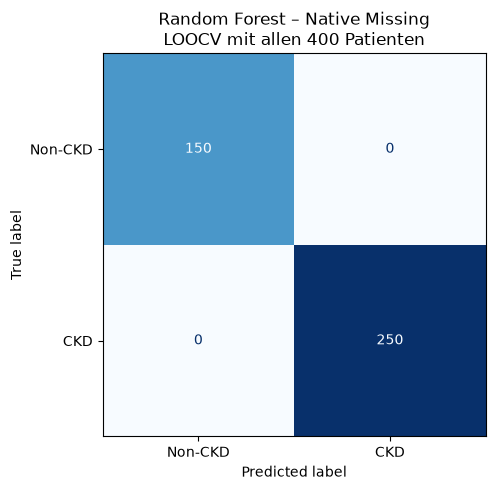

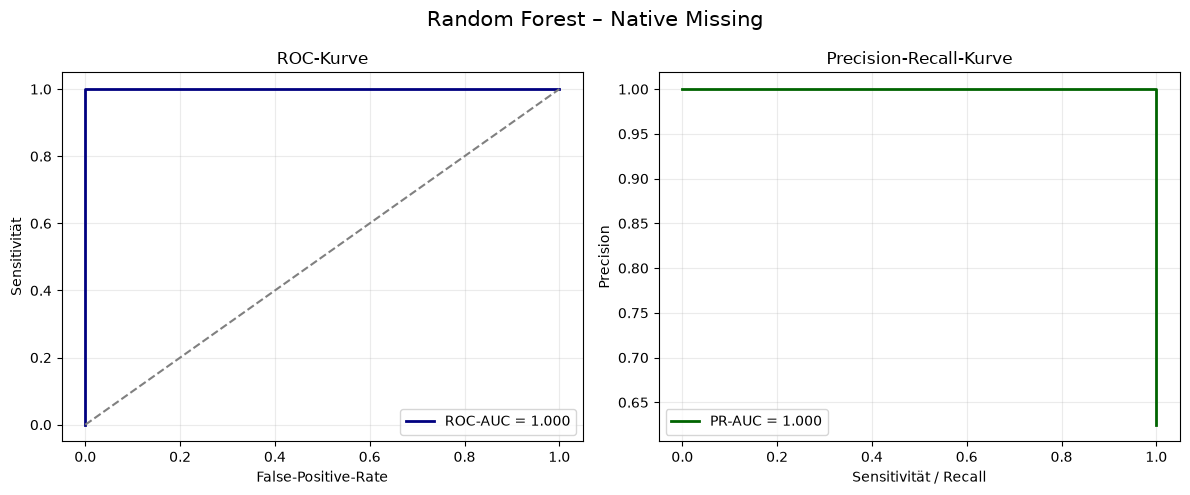


Falsch klassifizierte Patienten:
Keine falsch klassifizierten Patienten.

Die 20 unsichersten Vorhersagen:


,Tatsächliche Klasse,CKD-Wahrscheinlichkeit,Vorhergesagte Klasse,Korrekt,Abstand zur Entscheidungsgrenze
273,notckd,0.430,notckd,True,0.070
319,notckd,0.382,notckd,True,0.118
186,ckd,0.676,ckd,True,0.176
167,ckd,0.694,ckd,True,0.194
105,ckd,0.710,ckd,True,0.210
102,ckd,0.722,ckd,True,0.222
0,ckd,0.726,ckd,True,0.226
315,notckd,0.248,notckd,True,0.252
150,ckd,0.764,ckd,True,0.264
322,notckd,0.232,notckd,True,0.268



NATIVE-MISSING-LOOCV ABGESCHLOSSEN


In [15]:
# ============================================================
# RANDOM FOREST MIT NATIVER MISSING-VALUE-BEHANDLUNG
# LEAVE-ONE-OUT-CROSS-VALIDIERUNG AUF ALLEN 400 PATIENTEN
# ============================================================

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 1. GRUNDEINSTELLUNGEN
# ============================================================

RANDOM_STATE = 42
N_ESTIMATORS = 500

print("=" * 70)
print("RANDOM FOREST MIT NATIVER MISSING-VALUE-BEHANDLUNG")
print("LEAVE-ONE-OUT-CROSS-VALIDIERUNG")
print("=" * 70)

print("\nScikit-learn-Version:", sklearn.__version__)


# ============================================================
# 2. PRÜFEN, OB DIE INSTALLIERTE RANDOM-FOREST-VERSION
#    NUMERISCHE NaN-WERTE NATIV VERARBEITEN KANN
# ============================================================

def check_native_nan_support():
    """Prüft, ob RandomForestClassifier numerische NaN unterstützt."""

    X_test = np.array([
        [1.0],
        [2.0],
        [np.nan],
        [4.0],
        [5.0],
        [np.nan],
    ])

    y_test = np.array([
        0,
        0,
        0,
        1,
        1,
        1,
    ])

    test_model = RandomForestClassifier(
        n_estimators=10,
        random_state=RANDOM_STATE,
    )

    try:
        test_model.fit(X_test, y_test)
        test_model.predict(X_test)

        print(
            "\nDie installierte RandomForestClassifier-Version "
            "unterstützt numerische NaN-Werte."
        )

    except ValueError as error:
        raise RuntimeError(
            "\nDiese Scikit-learn-Version unterstützt NaN-Werte "
            "im RandomForestClassifier offenbar nicht.\n"
            "Das Experiment kann mit dieser Installation nicht "
            "als Native-Missing Random Forest durchgeführt werden.\n\n"
            f"Originalmeldung:\n{error}"
        )


check_native_nan_support()


# ============================================================
# 3. EINGABEDATEN UND ZIELVARIABLE VORBEREITEN
# ============================================================

# total enthält die bereinigten Eingabeparameter.
X_native = total.copy()

# Zielvariable aus classes extrahieren.
if isinstance(classes, pd.DataFrame):

    if "class" in classes.columns:
        y_text = classes["class"].copy()

    elif classes.shape[1] == 1:
        y_text = classes.iloc[:, 0].copy()

    else:
        raise ValueError(
            "classes muss die Spalte 'class' oder genau eine Spalte enthalten."
        )

else:
    y_text = classes.copy()


# Zielvariable anhand des Index an X ausrichten.
y_text = (
    y_text
    .reindex(X_native.index)
    .astype("string")
    .str.strip()
    .str.lower()
)


# Nur gültige Zielklassen behalten.
valid_target = y_text.isin([
    "ckd",
    "notckd",
])

X_native = X_native.loc[
    valid_target
].copy()

y_text = y_text.loc[
    valid_target
].copy()


# Binäre Kodierung:
# CKD     = 1
# Non-CKD = 0
y_native = (
    y_text
    .map({
        "notckd": 0,
        "ckd": 1,
    })
    .astype(int)
)


# Sicherstellen, dass kategoriale fehlende Werte als np.nan
# und nicht als pd.NA vorliegen.
for column in X_native.select_dtypes(
    include=[
        "object",
        "string",
        "category",
    ]
).columns:

    X_native[column] = X_native[column].astype("object")

    X_native.loc[
        X_native[column].isna(),
        column,
    ] = np.nan


print("\nAnzahl Patienten:", len(X_native))

print("\nKlassenverteilung:")
print(y_text.value_counts())

print("\nAnzahl fehlender Eingabewerte:")
print(int(X_native.isna().sum().sum()))


# ============================================================
# 4. NUMERISCHE UND KATEGORIALE SPALTEN BESTIMMEN
# ============================================================

numeric_columns = (
    X_native
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_columns = [
    column
    for column in X_native.columns
    if column not in numeric_columns
]


print("\nNumerische Spalten:")
print(numeric_columns)

print("\nKategoriale Spalten:")
print(categorical_columns)


# ============================================================
# 5. VORVERARBEITUNG OHNE IMPUTATION
# ============================================================

# Numerische Variablen:
# passthrough bedeutet, dass die NaN-Werte unverändert
# an den Random Forest übergeben werden.

# Kategoriale Variablen:
# OneHotEncoder behandelt np.nan als eigene Kategorie.
# Es wird kein Modus eingesetzt.

preprocessor_native = ColumnTransformer(
    transformers=[
        (
            "numerisch_native",
            "passthrough",
            numeric_columns,
        ),
        (
            "kategorial",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float64,
            ),
            categorical_columns,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)


# ============================================================
# 6. RANDOM FOREST DEFINIEREN
# ============================================================

random_forest_native = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=1,
)


native_pipeline = Pipeline(
    steps=[
        (
            "vorverarbeitung",
            preprocessor_native,
        ),
        (
            "modell",
            random_forest_native,
        ),
    ]
)


# ============================================================
# 7. LEAVE-ONE-OUT-CROSS-VALIDIERUNG
# ============================================================

loo = LeaveOneOut()

print("\n" + "=" * 70)
print("STARTE LEAVE-ONE-OUT-CROSS-VALIDIERUNG")
print("=" * 70)

print(
    f"\nEs werden {len(X_native)} Modelle trainiert."
)

print(
    "In jeder Runde werden 399 Patienten zum Training "
    "und eine Person zur Validierung verwendet."
)

print(
    "Es findet keine numerische Imputation statt."
)

start_time = time.time()


# Für jede ausgelassene Person wird die CKD-Wahrscheinlichkeit
# aus einem Modell berechnet, das diese Person nicht gesehen hat.
predicted_probabilities = cross_val_predict(
    estimator=native_pipeline,
    X=X_native,
    y=y_native,
    cv=loo,
    method="predict_proba",
    n_jobs=-1,
    verbose=10,
)


runtime_minutes = (
    time.time() - start_time
) / 60


# Spalte 1 entspricht der positiven Klasse CKD = 1.
ckd_probability = predicted_probabilities[:, 1]


# Klassifikation mit Entscheidungsgrenze 0,5.
predicted_class = (
    ckd_probability >= 0.5
).astype(int)


print("\nLeave-One-Out abgeschlossen.")

print(
    f"Laufzeit: {runtime_minutes:.2f} Minuten"
)


# ============================================================
# 8. CONFUSION MATRIX UND KENNZAHLEN
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_native,
    predicted_class,
    labels=[0, 1],
).ravel()


specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)


results_native = pd.DataFrame([
    {
        "Modell": "Random Forest – Native Missing",
        "Population": "Alle Patienten",
        "Anzahl Patienten": len(y_native),

        "Accuracy": accuracy_score(
            y_native,
            predicted_class,
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_native,
            predicted_class,
        ),

        "Precision": precision_score(
            y_native,
            predicted_class,
            zero_division=0,
        ),

        "Sensitivität": recall_score(
            y_native,
            predicted_class,
            pos_label=1,
            zero_division=0,
        ),

        "Spezifität": specificity,

        "F1-Score": f1_score(
            y_native,
            predicted_class,
            zero_division=0,
        ),

        "ROC-AUC": roc_auc_score(
            y_native,
            ckd_probability,
        ),

        "PR-AUC": average_precision_score(
            y_native,
            ckd_probability,
        ),

        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
    }
])


metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivität",
    "Spezifität",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
]

results_native[metric_columns] = (
    results_native[metric_columns]
    .round(3)
)


print("\nErgebnisse der LOOCV:")

display(results_native)


# ============================================================
# 9. CONFUSION MATRIX DARSTELLEN
# ============================================================

figure, axis = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=np.array([
        [tn, fp],
        [fn, tp],
    ]),
    display_labels=[
        "Non-CKD",
        "CKD",
    ],
).plot(
    ax=axis,
    cmap="Blues",
    colorbar=False,
)

axis.set_title(
    "Random Forest – Native Missing\nLOOCV mit allen 400 Patienten"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. ROC-KURVE UND PRECISION-RECALL-KURVE
# ============================================================

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_native,
    ckd_probability,
)

precision_values, recall_values, _ = precision_recall_curve(
    y_native,
    ckd_probability,
)


figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
)


# ROC-Kurve
axes[0].plot(
    false_positive_rate,
    true_positive_rate,
    color="navy",
    linewidth=2,
    label=(
        "ROC-AUC = "
        f"{roc_auc_score(y_native, ckd_probability):.3f}"
    ),
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
)

axes[0].set_title("ROC-Kurve")
axes[0].set_xlabel("False-Positive-Rate")
axes[0].set_ylabel("Sensitivität")
axes[0].legend()
axes[0].grid(alpha=0.25)


# Precision-Recall-Kurve
axes[1].plot(
    recall_values,
    precision_values,
    color="darkgreen",
    linewidth=2,
    label=(
        "PR-AUC = "
        f"{average_precision_score(y_native, ckd_probability):.3f}"
    ),
)

axes[1].set_title("Precision-Recall-Kurve")
axes[1].set_xlabel("Sensitivität / Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.25)


figure.suptitle(
    "Random Forest – Native Missing",
    fontsize=15,
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. VORHERSAGEN PRO PATIENT SPEICHERN
# ============================================================

predictions_native = pd.DataFrame(
    {
        "Tatsächliche Klasse": y_text,
        "CKD-Wahrscheinlichkeit": ckd_probability,
        "Vorhergesagte Klasse": np.where(
            predicted_class == 1,
            "ckd",
            "notckd",
        ),
    },
    index=X_native.index,
)


predictions_native["Korrekt"] = (
    predictions_native["Tatsächliche Klasse"]
    == predictions_native["Vorhergesagte Klasse"]
)


predictions_native[
    "Abstand zur Entscheidungsgrenze"
] = (
    predictions_native[
        "CKD-Wahrscheinlichkeit"
    ]
    - 0.5
).abs()


# ============================================================
# 12. FEHLKLASSIFIZIERTE PATIENTEN AUSGEBEN
# ============================================================

misclassified_native = (
    predictions_native.loc[
        ~predictions_native["Korrekt"]
    ]
    .sort_values(
        "Abstand zur Entscheidungsgrenze"
    )
)


print("\nFalsch klassifizierte Patienten:")

if misclassified_native.empty:

    print(
        "Keine falsch klassifizierten Patienten."
    )

else:

    display(
        misclassified_native.round(3)
    )


# ============================================================
# 13. UNSICHERSTE VORHERSAGEN AUSGEBEN
# ============================================================

uncertain_native = (
    predictions_native
    .sort_values(
        "Abstand zur Entscheidungsgrenze"
    )
    .head(20)
)


print("\nDie 20 unsichersten Vorhersagen:")

display(
    uncertain_native.round(3)
)


print("\n" + "=" * 70)
print("NATIVE-MISSING-LOOCV ABGESCHLOSSEN")
print("=" * 70)

Der Random Forest mit nativer Verarbeitung fehlender numerischer Werte erreichte in der Leave-One-Out-Cross-Validation eine perfekte interne Klassifikation aller 400 Fälle. Gegenüber der Imputation mit Missing-Indikatoren verbesserte sich das Ergebnis jedoch lediglich um eine einzige Beobachtung. Das Resultat zeigt eine außergewöhnlich starke Trennbarkeit innerhalb des vorliegenden Datensatzes. Aufgrund der nachgewiesenen Assoziation zwischen Missingness und CKD-Status ist davon auszugehen, dass das Modell neben medizinischen Merkmalen auch Muster des Erhebungs- und Dokumentationsprozesses nutzt. Eine Übertragbarkeit auf andere Kliniken kann daraus nicht abgeleitet werden.

Die nahezu perfekte interne Modellleistung ist deshalb kein Nachweis einer klinischen Einsatzfähigkeit. Der Datensatz bildet nur eine kleine Kohorte aus einem Krankenhaus und einem kurzen Erhebungszeitraum ab. Als nächster methodischer Schritt wäre eine externe Validierung mit Daten aus anderen Krankenhäusern oder eine zeitbasierte Validierung mit später erhobenen Patientendaten erforderlich.